# GReLU quantized neuron on XX vs XXX thermal states — full pipeline

The whole study in one notebook: data → split → the neuron and its training algorithms (GReLU **Algorithms 8 and 9**) → classifying by **firing** the neuron (Gaussian **Algorithm 5**, including an explicit ITensor qumode) → the classical feed-forward control → metrics and figures → the report.

Write-up: [`REPORT.md`](REPORT.md) / [`REPORT.pdf`](REPORT.pdf). Paper: He, Liu & Wilde, *Fermi–Dirac machines as quantizations of neurons* (arXiv:2605.24386).

**How this notebook runs**
- Fast steps run here, in the notebook: loading and verifying the data, the model, a gradient check, a short training run, firing, and a single-state qumode simulation.
- The full experiments run as subprocesses, using exactly the scripts in `src/`, so their results are identical to the command-line runs.
- With `RERUN = false` (the default) the long experiments (~2.5 h on an M1 Pro) are **not** re-run; their saved results in `results/` are summarised and plotted. Set `RERUN = true` on a fresh clone, where `results/` is empty.

**Requirements:** the Julia packages HDF5, Optimisers, Plots, SpecialFunctions, ITensors and ITensorMPS. The dataset files `xx_xxx_n10.h5` and `fixture_n4.h5` must be in `data/xx_xxx_thermal_states/` (see that folder's `HANDOFF.md` and `SHA256SUMS`).

## 0. Setup

In [1]:
RERUN = false          # true: re-run every long experiment (~2.5 h); false: use saved results/

"The repository root: the first directory upwards that contains experiments/xx_xxx_grelu."
function find_root(dir=pwd())
    while !isdir(joinpath(dir, "experiments", "xx_xxx_grelu"))
        parent = dirname(dir)
        parent == dir && error("start the notebook from inside the repository")
        dir = parent
    end
    return dir
end
isdefined(Main, :NBROOT) || (const NBROOT = find_root())
isdefined(Main, :EXPDIR) || (const EXPDIR = joinpath(NBROOT, "experiments", "xx_xxx_grelu"))
cd(NBROOT)
isdefined(Main, :CFG) || include(joinpath(EXPDIR, "src", "train_xx_xxx_grelu.jl"))   # neuron + data + drivers
using Printf, Statistics, LinearAlgebra, Random

"Run one of the pipeline scripts exactly as on the command line."
runscript(script, args...) = (run(`$(Base.julia_cmd()) $(joinpath(EXPDIR, "src", script)) $args`); nothing)

"Read a CSV written by the pipeline into a Dict of columns."
function readres(name)
    lines = readlines(joinpath(OUT, name))
    hdr = split(lines[1], ',')
    rows = [split(l, ',') for l in lines[2:end]]
    pc(v) = (x = tryparse(Float64, v); x === nothing ? String(v) : x)
    Dict(String(h) => [pc(r[i]) for r in rows] for (i, h) in enumerate(hdr))
end
showfig(name) = display("image/png", read(joinpath(EXPDIR, "figures", name * ".png")))
println("repository root: ", NBROOT, "\nresults: ", OUT, "\nRERUN = ", RERUN)

repository root: /Users/mohamedzakariakheder/Documents/academic/meng project/tensor network method testing


results: /Users/mohamedzakariakheder/Documents/academic/meng project/tensor network method testing/experiments/xx_xxx_grelu/results
RERUN = false


## 1. Validation suite

19 checks on the n = 4 fixture:
- **reader:** the contracted MPOs reproduce the file's stored trace distances;
- **Pauli algebra:** matches explicit Kronecker products;
- **exact gradients:** match finite differences;
- **estimators:** the Monte-Carlo Algorithms 8 and 9 are unbiased;
- **value estimator and Algorithm 5 firing:** match the exact outputs.

In [2]:
runscript("test_grelu_neuron.jl")


1. reader


/Users/mohamedzakariakheder/Documents/academic/meng project/tensor network method testing/experiments/xx_xxx_grelu/src/../../../data/xx_xxx_thermal_states/fixture_n4.h5
  n = 4   24 samples   8 chains (4 XX / 4 XXX)   kT = [1.0, 0.5, 0.25]


  ED vs file: max|dE| = 9.8e-15   max|dlogZ| = 2.5e-14   (2.6s)


  pass  chi4: our MPO-vs-ED trace distance matches the file's (max diff 8.3e-16, td up to 6.6e-01)
  pass  chi8: our MPO-vs-ED trace distance matches the file's (max diff 9.0e-16, td up to 3.7e-01)


  pass  split keeps every chain (all its kT rungs) on one side

2. Pauli algebra


...

  pass  Alg 8, exact circuit expectations      max |z| = 1.67   rel err 0.197


  pass  Alg 8, single shots                    max |z| = 1.97   rel err 3.452


  pass  Alg 8, single shots, literal value circuit max |z| = 1.73   rel err 3.880

5. neuron value estimator


  pass  value_estimate vs exact on 6 states: max |z| = 1.44

6. Gaussian Algorithm 5 (the neuron firing)


  pass  mean firing = Tr[GReLU(H) rho] on 6 states: max |z| = 1.36
  pass  fire(H) - fire(-H) = Tr[H rho] (Alg 9 decision): max |z| = 0.86

all checks passed


## 2. Data

840 thermal states ρ = e^{−βH}/Z of random 10-site chains, 42 XX and 42 XXX chains × 10 temperatures kT = 2 … 0.1. Each ρ is rebuilt **exactly** from its stored couplings J by diagonalisation. The loader checks every energy and log Z against the file's dense-ED reference.

In [3]:
ds = XXXData.load(DATA)
@printf("%d states, %d chains, labels: %d XX / %d XXX\n", length(ds), length(unique(ds.group)),
        count(==(0), ds.label), count(==(1), ds.label))

/Users/mohamedzakariakheder/Documents/academic/meng project/tensor network method testing/data/xx_xxx_thermal_states/xx_xxx_n10.h5
  n = 10   840 samples   84 chains (42 XX / 42 XXX)   kT = [2.0, 1.41, 1.0, 0.71, 0.5, 0.35, 0.25, 0.18, 0.13, 0.1]
  ED vs file: max|dE| = 7.8e-14   max|dlogZ| = 4.3e-13   (9.3s)


840 states, 84 chains, labels: 420 XX / 420 XXX


**Train/test split.** Whole chains (all 10 temperatures) go to one side: 8 XX + 8 XXX chains for test, and the other 68 chains in 5 stratified folds for cross-validation (seed 20260923). The `split` step also contracts each chain's stored MPO and checks it against the exact ρ. This is why the pipeline uses the exact ρ rather than the truncated MPO.

In [4]:
RERUN && runscript("train_xx_xxx_grelu.jl", "split")
split_, fold = load_split(ds)
XXXData.describe_split(ds, split_, fold)

  train  680 samples  68 chains  (34 XX / 34 XXX chains)
  test   160 samples  16 chains  (8 XX / 8 XXX chains)


  fold 1 140 samples  14 chains  (7 XX / 7 XXX)
  fold 2 140 samples  14 chains  (7 XX / 7 XXX)
  fold 3 140 samples  14 chains  (7 XX / 7 XXX)
  fold 4 140 samples  14 chains  (7 XX / 7 XXX)
  fold 5 120 samples  12 chains  (6 XX / 6 XXX)


**Why the classes separate.** XXX is SU(2)-symmetric, so its thermal states have ⟨ZZ⟩ = ⟨XX⟩ = ⟨YY⟩ on every bond; XX states have weaker ⟨ZZ⟩.

XX   kT = 2     <ZZ> -0.180   <(XX+YY)/2> -0.412
XX   kT = 0.1   <ZZ> -0.463   <(XX+YY)/2> -0.657


XXX  kT = 2     <ZZ> -0.452   <(XX+YY)/2> -0.452
XXX  kT = 0.1   <ZZ> -0.615   <(XX+YY)/2> -0.615


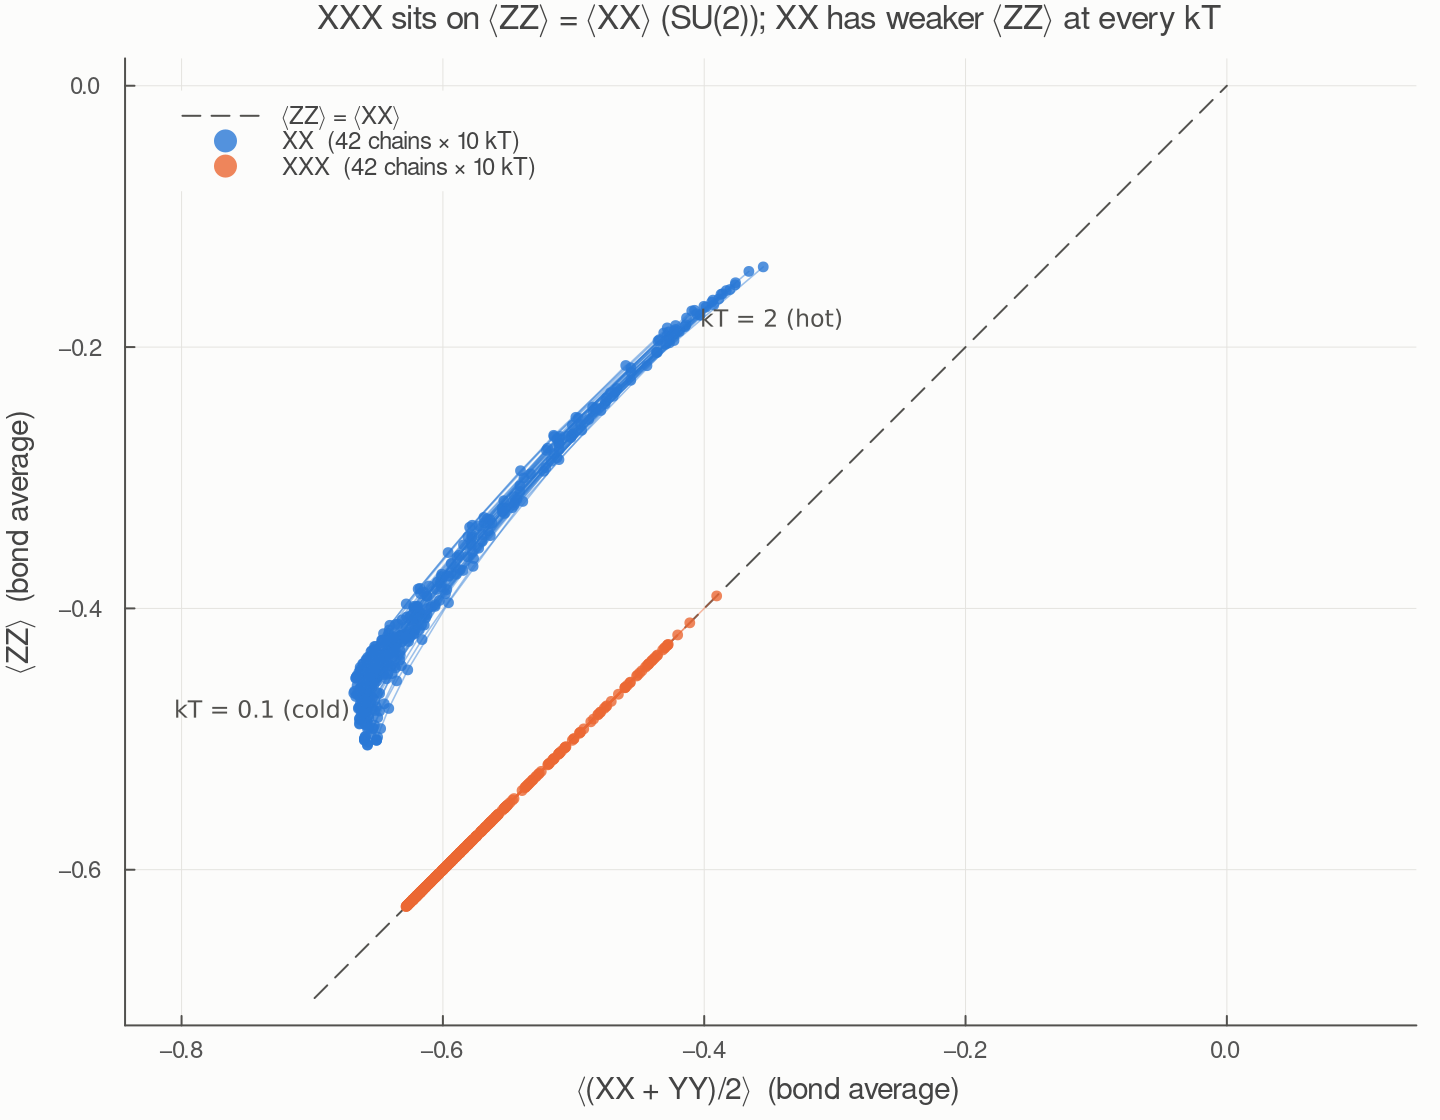

In [5]:
c = readres("correlators.csv")
for model in ("XX", "XXX"), kT in (2.0, 0.1)
    m = (c["model"] .== model) .& (c["kT"] .== kT)
    @printf("%-4s kT = %-4g  <ZZ> %.3f   <(XX+YY)/2> %.3f\n", model, kT, mean(c["zz"][m]),
            mean((c["xx"][m] .+ c["yy"][m]) ./ 2))
end
showfig("A2_correlators")

## 3. The neuron and its training algorithms

H(θ) = Σ_j θ_j H_j over the 37 terms Z_i, Z_iZ_{i+1}, X_iX_{i+1}, Y_iY_{i+1}. The neuron's output is Tr[GReLU_T(H(θ)) ρ], with GReLU_T(x) = xΦ(x/T) + Tφ(x/T). Two training routes:
- **Algorithm 9 (margin loss):** L = (1/M) Σ Tr[GReLU_T(−y_m H) ρ_m]. It classifies by sign Tr[Hρ] and has no bias term.
- **Algorithm 8 (squared loss):** L = (1/M) Σ (Tr[GReLU_T(H) ρ_m] − ỹ_m)², with ỹ ∈ {0, 1}. It classifies by output > ½ and needs a bias term.

Below, the exact gradient (Daleckii–Krein, the infinite-shot limit) is compared with the single-shot Monte-Carlo algorithms at the initial θ.

In [6]:
hp = Dict(k => chosen(k) for k in (:margin, :square))
println("hyperparameters chosen by cross-validation: ", hp)
P9 = problems(ds, split_, :margin)      # (train Problem, test Problem, train idx, test idx, paulis)
P8 = problems(ds, split_, :square)
θ0_9 = CFG.init_scale .* randn(MersenneTwister(CFG.seed), length(P9[1].paulis))
θ0_8 = CFG.init_scale .* randn(MersenneTwister(CFG.seed), length(P8[1].paulis))

_, g9 = margin_loss_grad(P9[1], θ0_9)
ĝ9 = alg9_grelu_gradient(P9[1], θ0_9; nsamples=256, rng=MersenneTwister(1))
_, g8, _ = square_loss_grad(P8[1], θ0_8, (P8[1].y .+ 1) ./ 2)
ĝ8 = alg8_grelu_gradient(P8[1], θ0_8, (P8[1].y .+ 1) ./ 2; nsamples=64, rng=MersenneTwister(1))
cosine(a, b) = dot(a, b) / (norm(a) * norm(b))
@printf("Alg 9, 256 single-shot circuit runs: relative error %.2f, cosine to exact %.2f\n", norm(ĝ9 - g9) / norm(g9), cosine(ĝ9, g9))
@printf("Alg 8,  64 single-shot circuit runs: relative error %.2f, cosine to exact %.2f\n", norm(ĝ8 - g8) / norm(g8), cosine(ĝ8, g8))

hyperparameters chosen by cross-validation: Dict

(:margin => (T = 1.0, l2 = 0.001), :square => (T = 1.0, l2 = 0.0001))
Alg 9, 256 single-shot circuit runs: relative error 1.78, cosine to exact 0.54
Alg 8,  64 single-shot circuit runs: relative error 54.97, cosine to exact 0.06


**Hyperparameters** (5-fold grouped cross-validation, ~45 min) and the **exact-gradient training** of both neurons. The training is short enough to run right here: 200 Adam steps from the same seeded θ₀ as the saved runs.

In [7]:
RERUN && runscript("train_xx_xxx_grelu.jl", "cv")
res9 = train(:margin, P9[1], P9[2]; l2=hp[:margin].l2, monitor=false, verbose=false)
res8 = train(:square, P8[1], P8[2]; l2=hp[:square].l2, monitor=false, verbose=false)
for (name, res) in (("Alg 9", res9), ("Alg 8", res8))
    h = res.hist[end]
    @printf("%s: test accuracy %.3f  AUC %.3f   ||θ||₁ = %.1f   (%.0f s)\n", name, h.test_acc, h.test_auc,
            norm(res.theta, 1), res.wall)
end

Alg 9: test accuracy 1.000  AUC 1.000   ||θ||₁ = 2.4   (85 s)
Alg 8: test accuracy 1.000  AUC 1.000   ||θ||₁ = 33.0   (140 s)


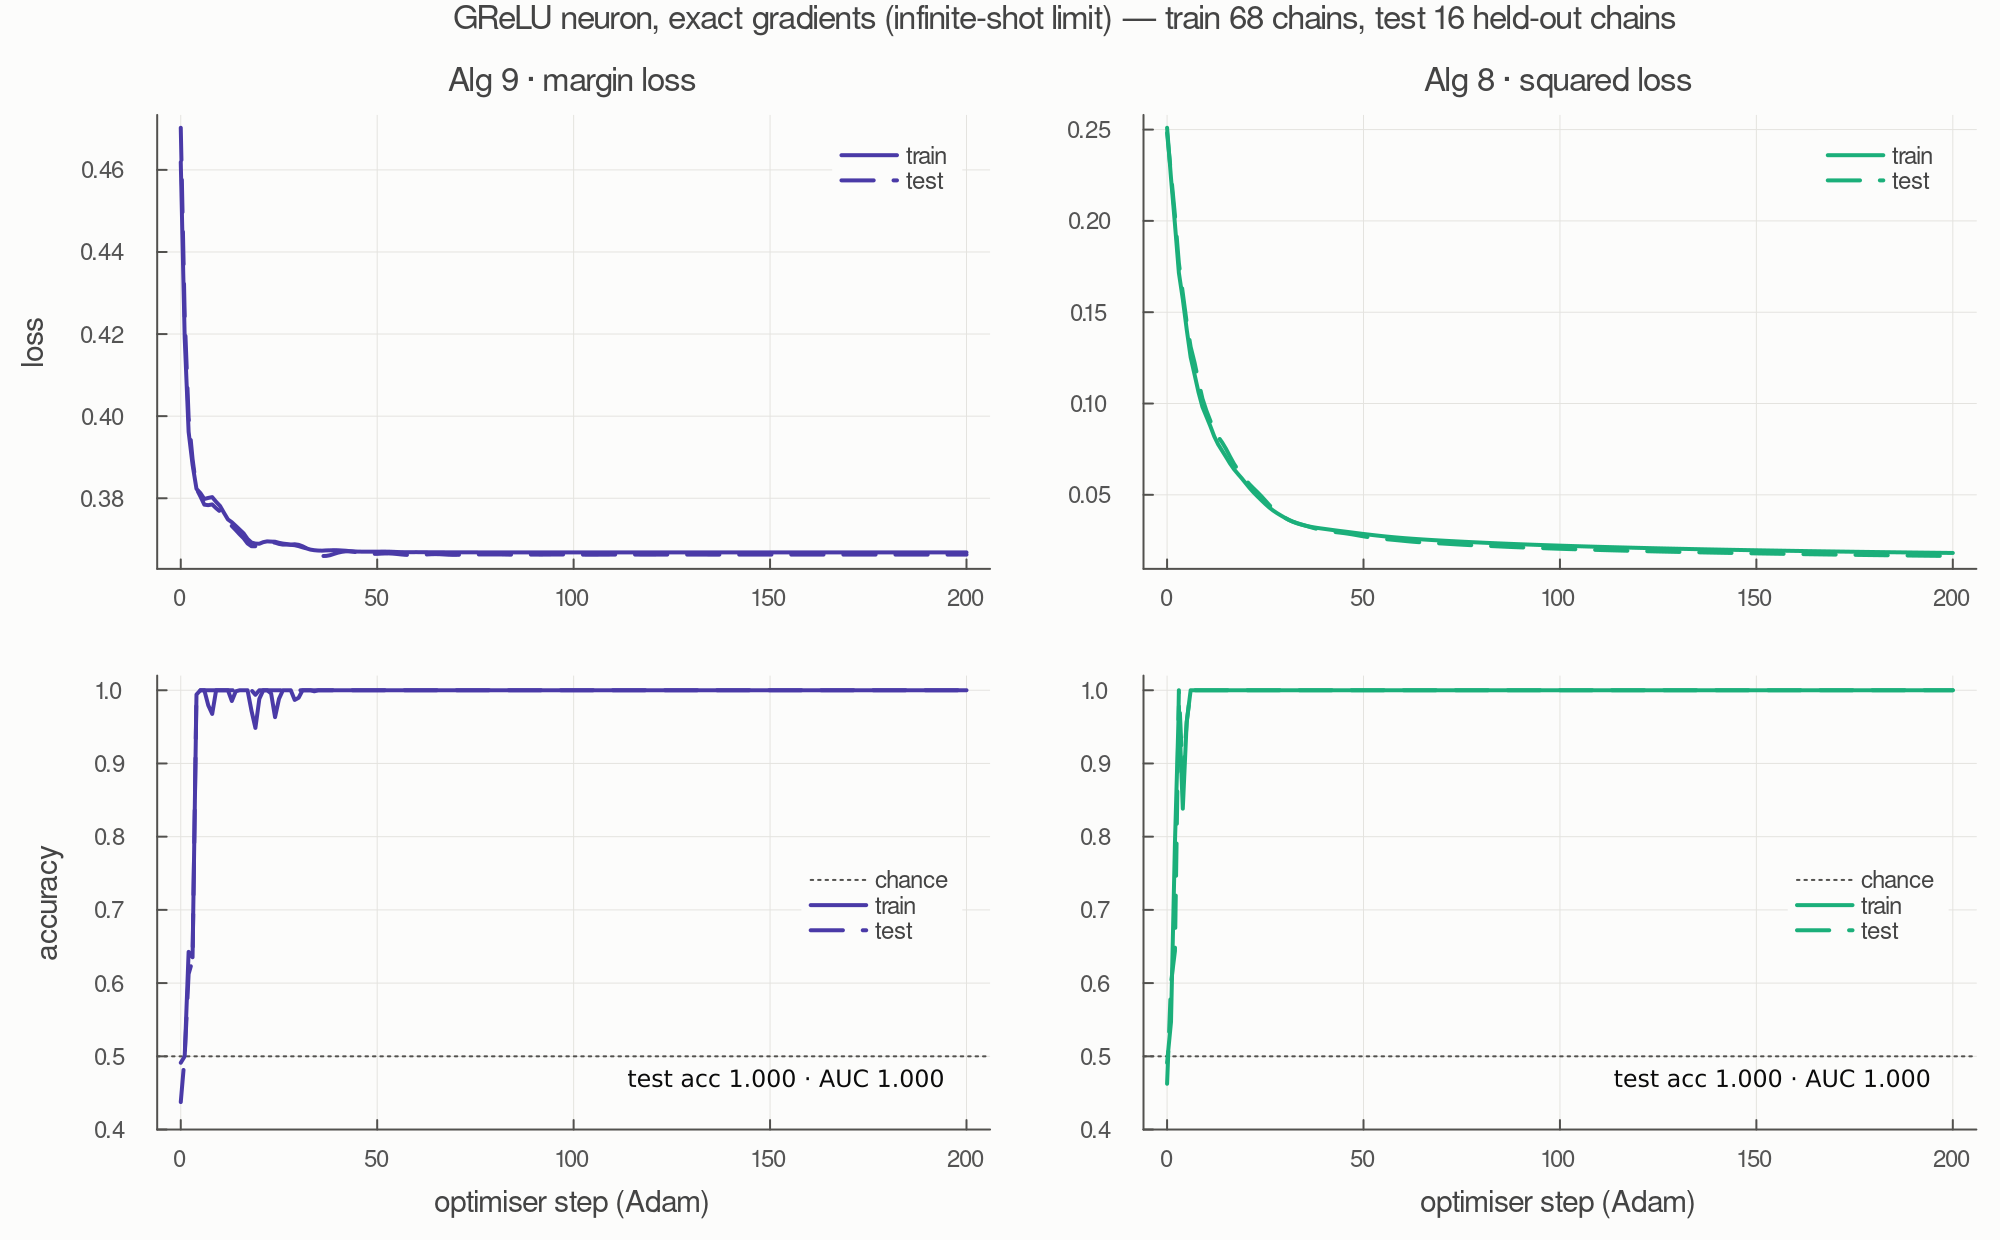

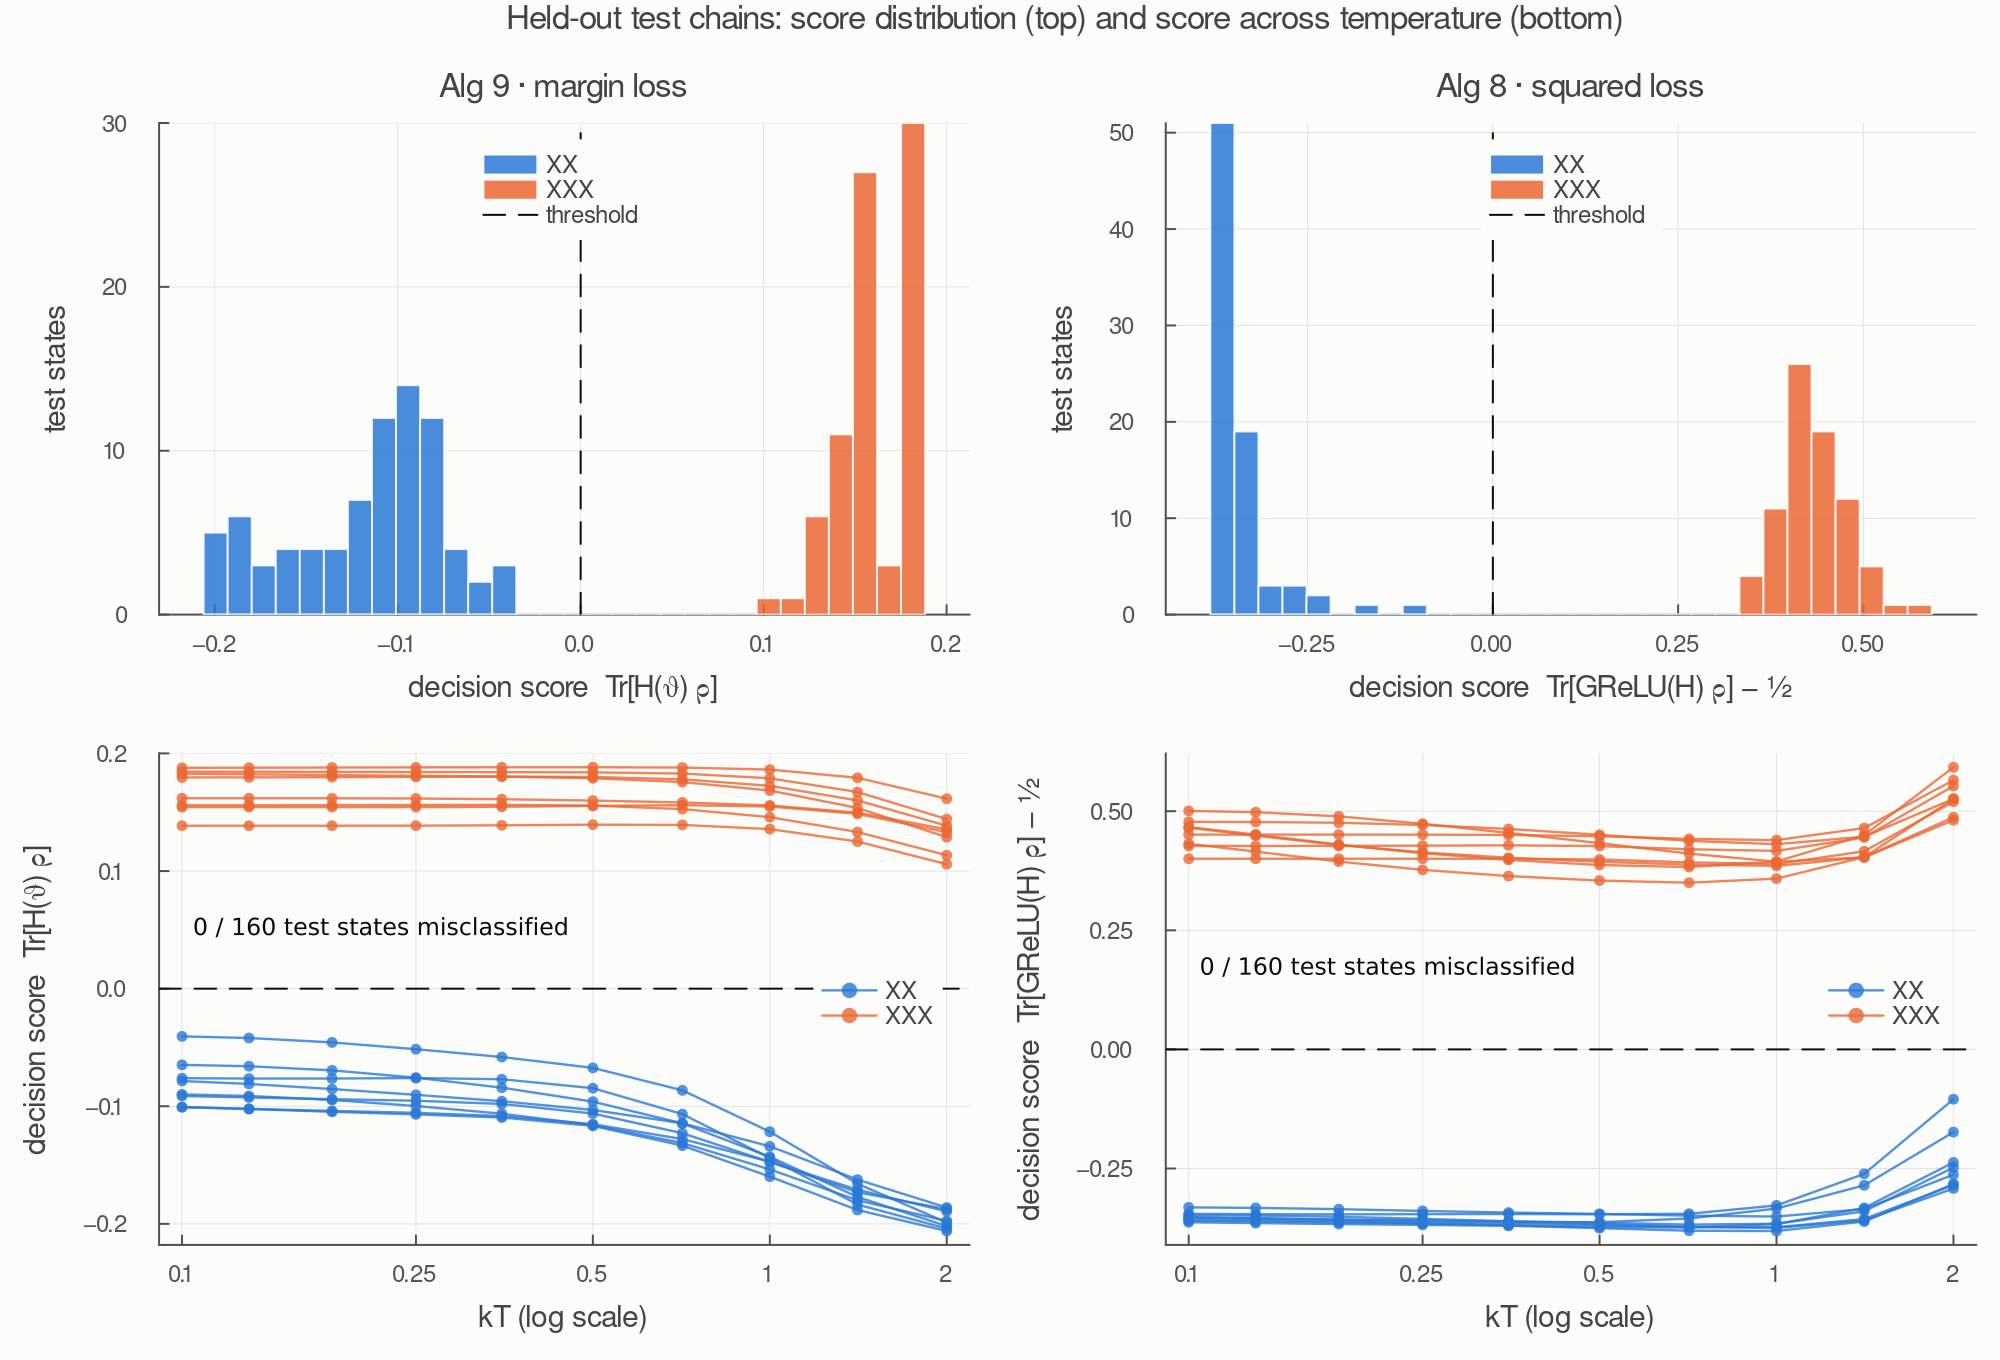

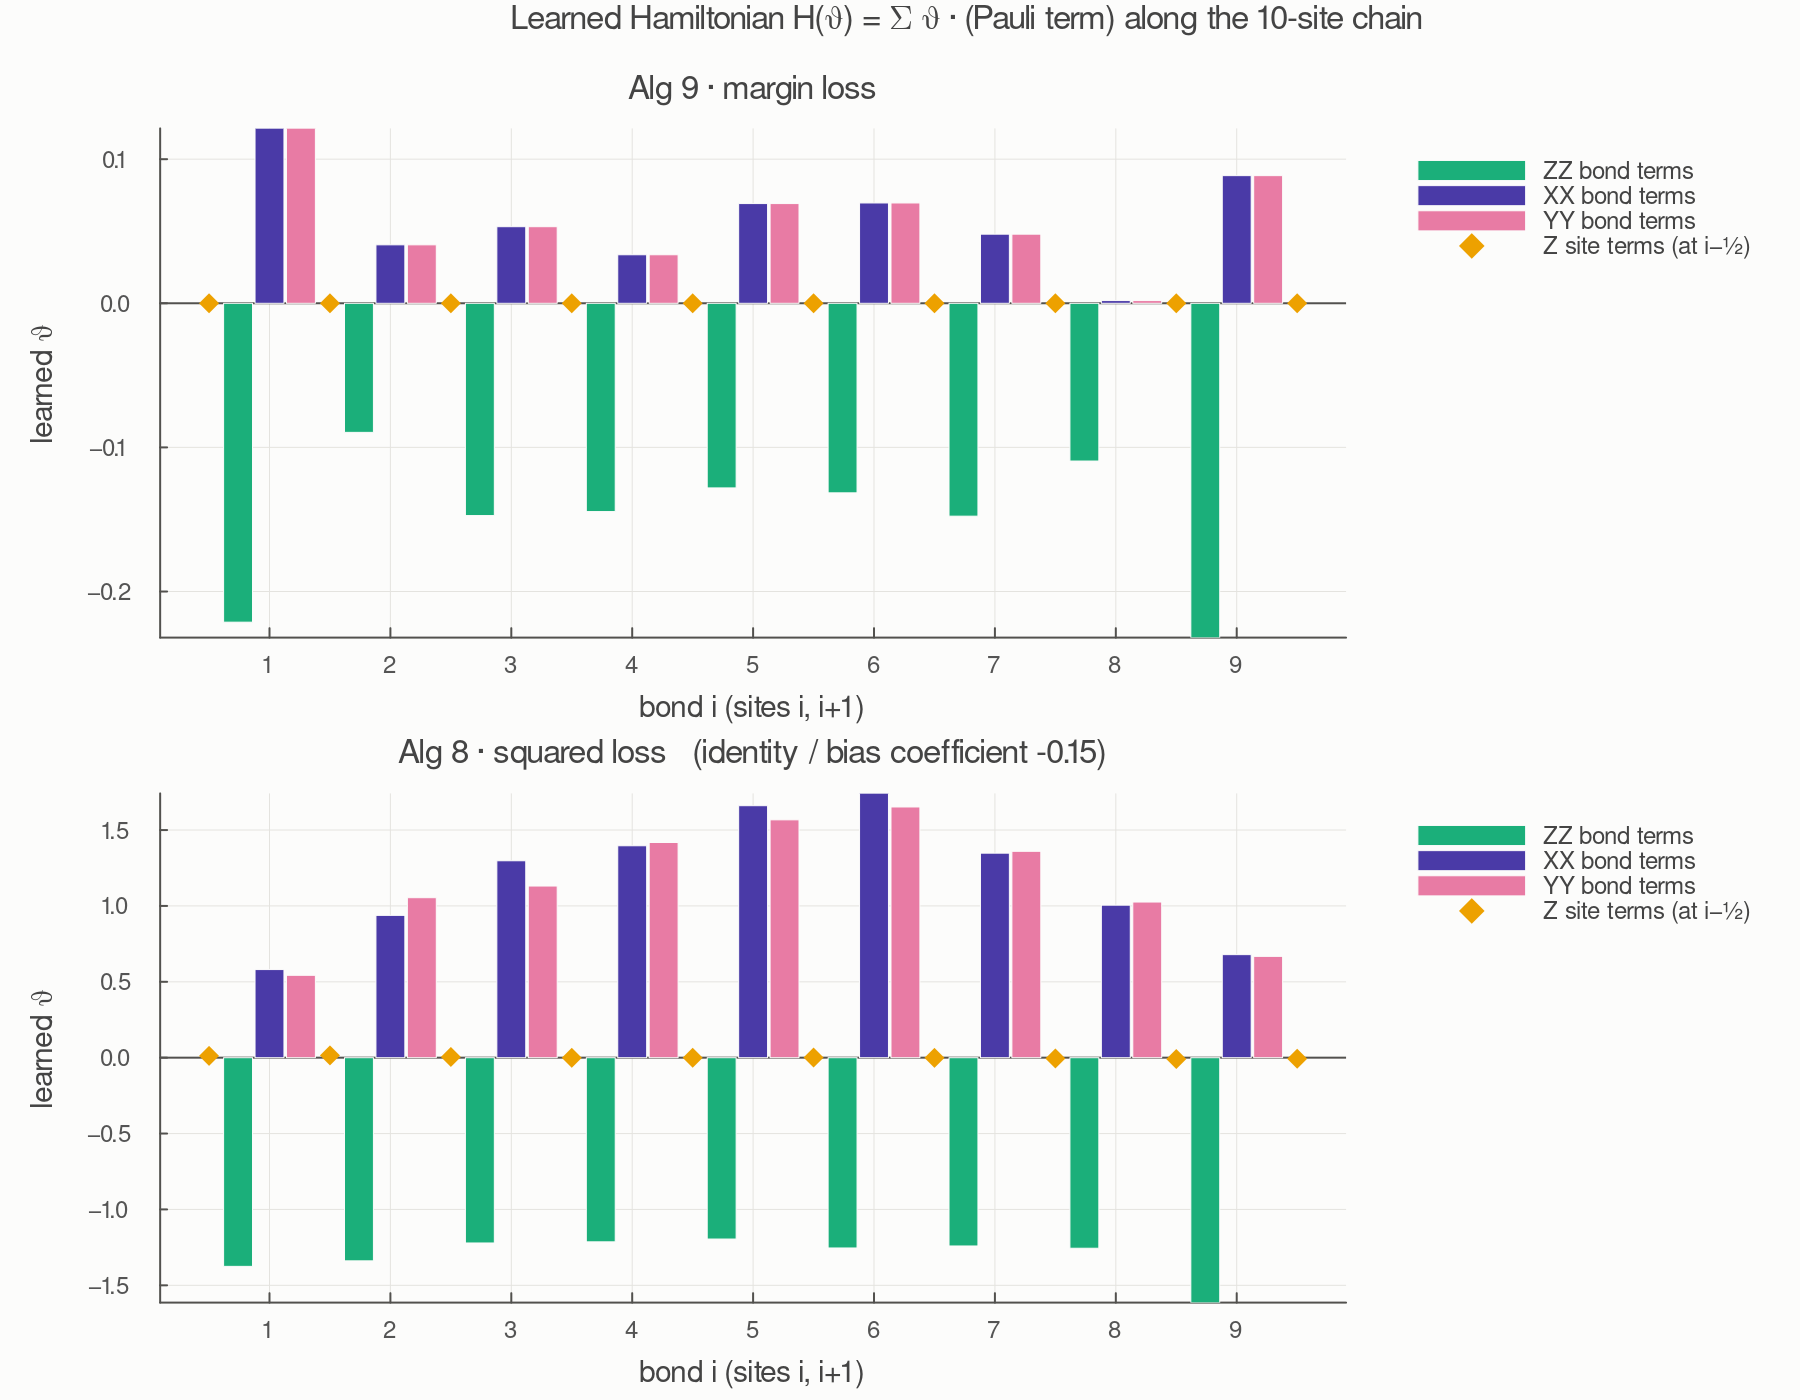

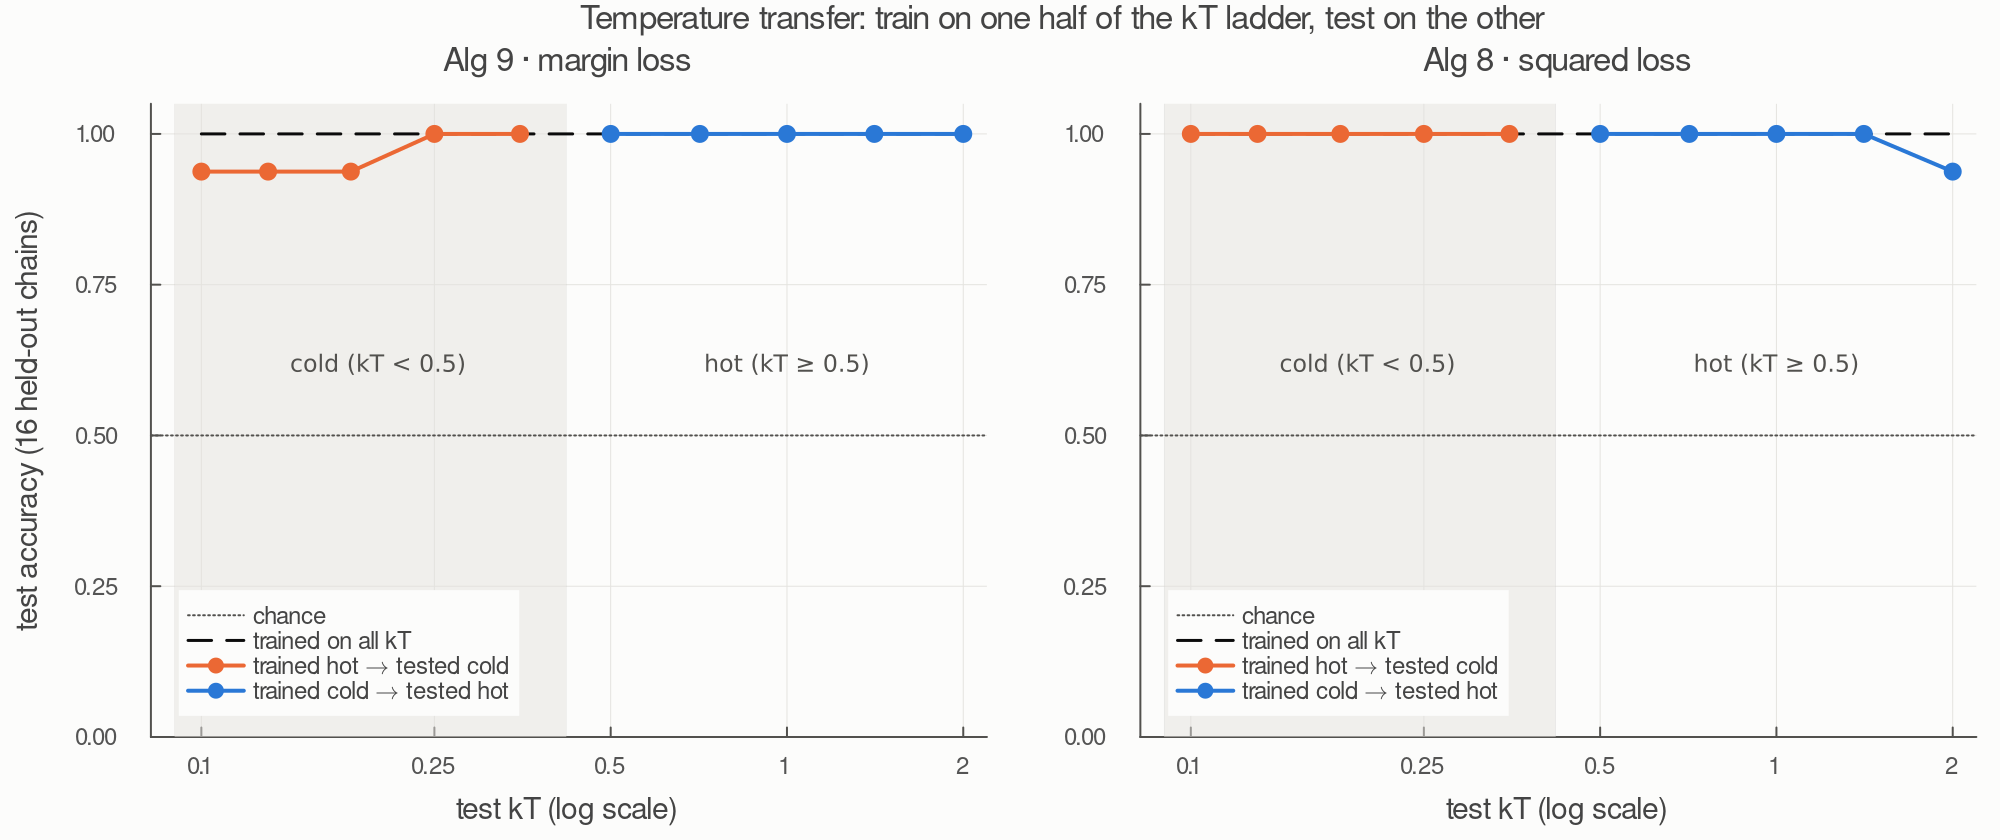

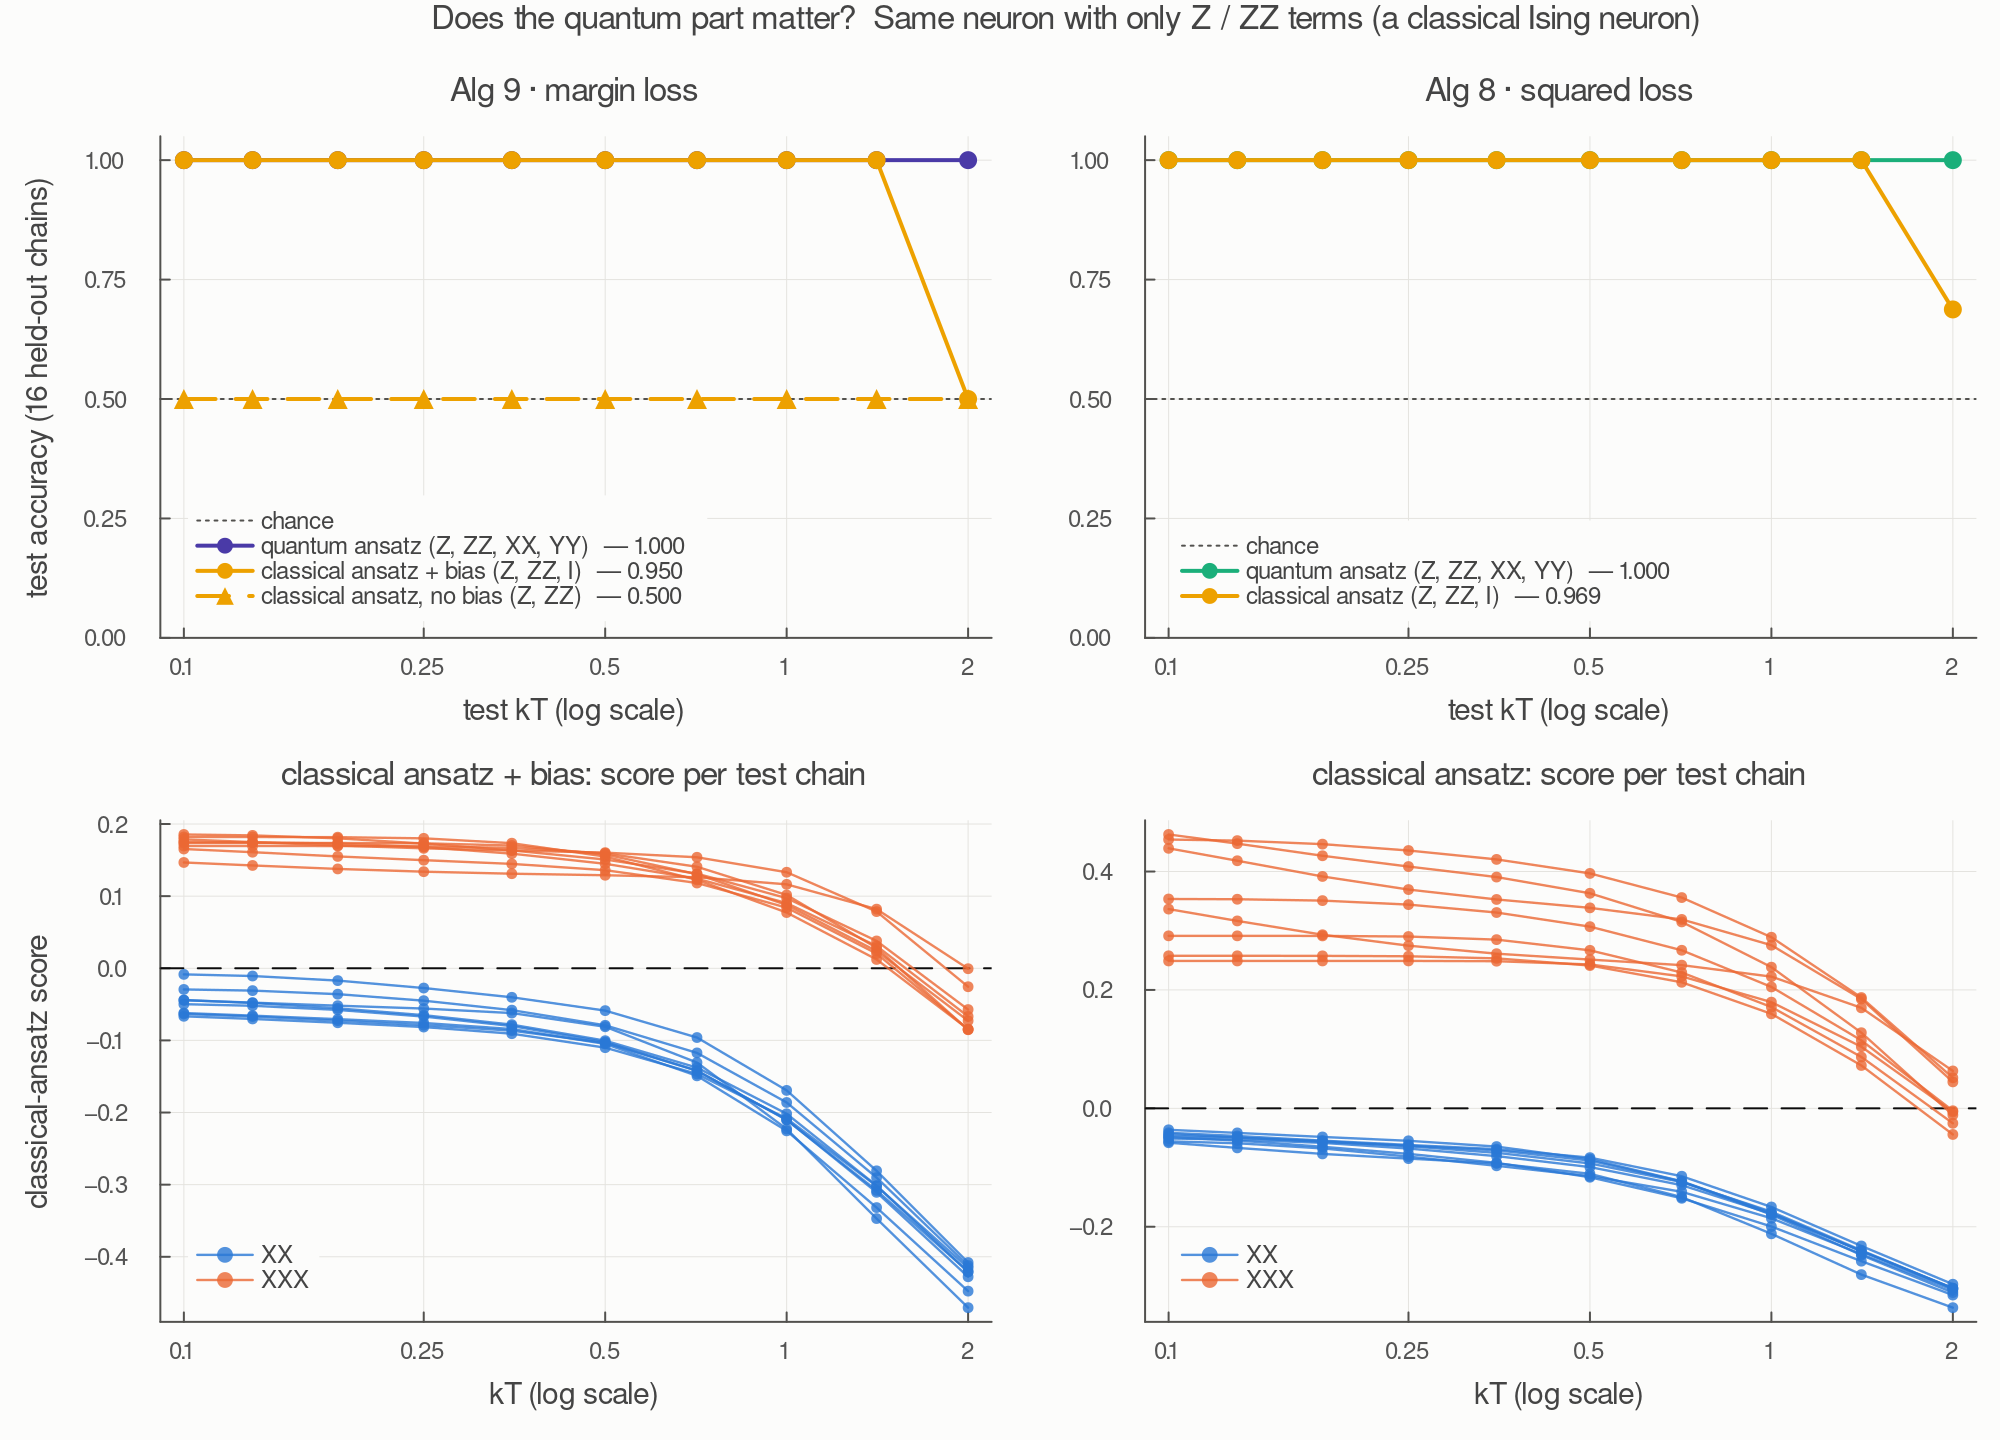

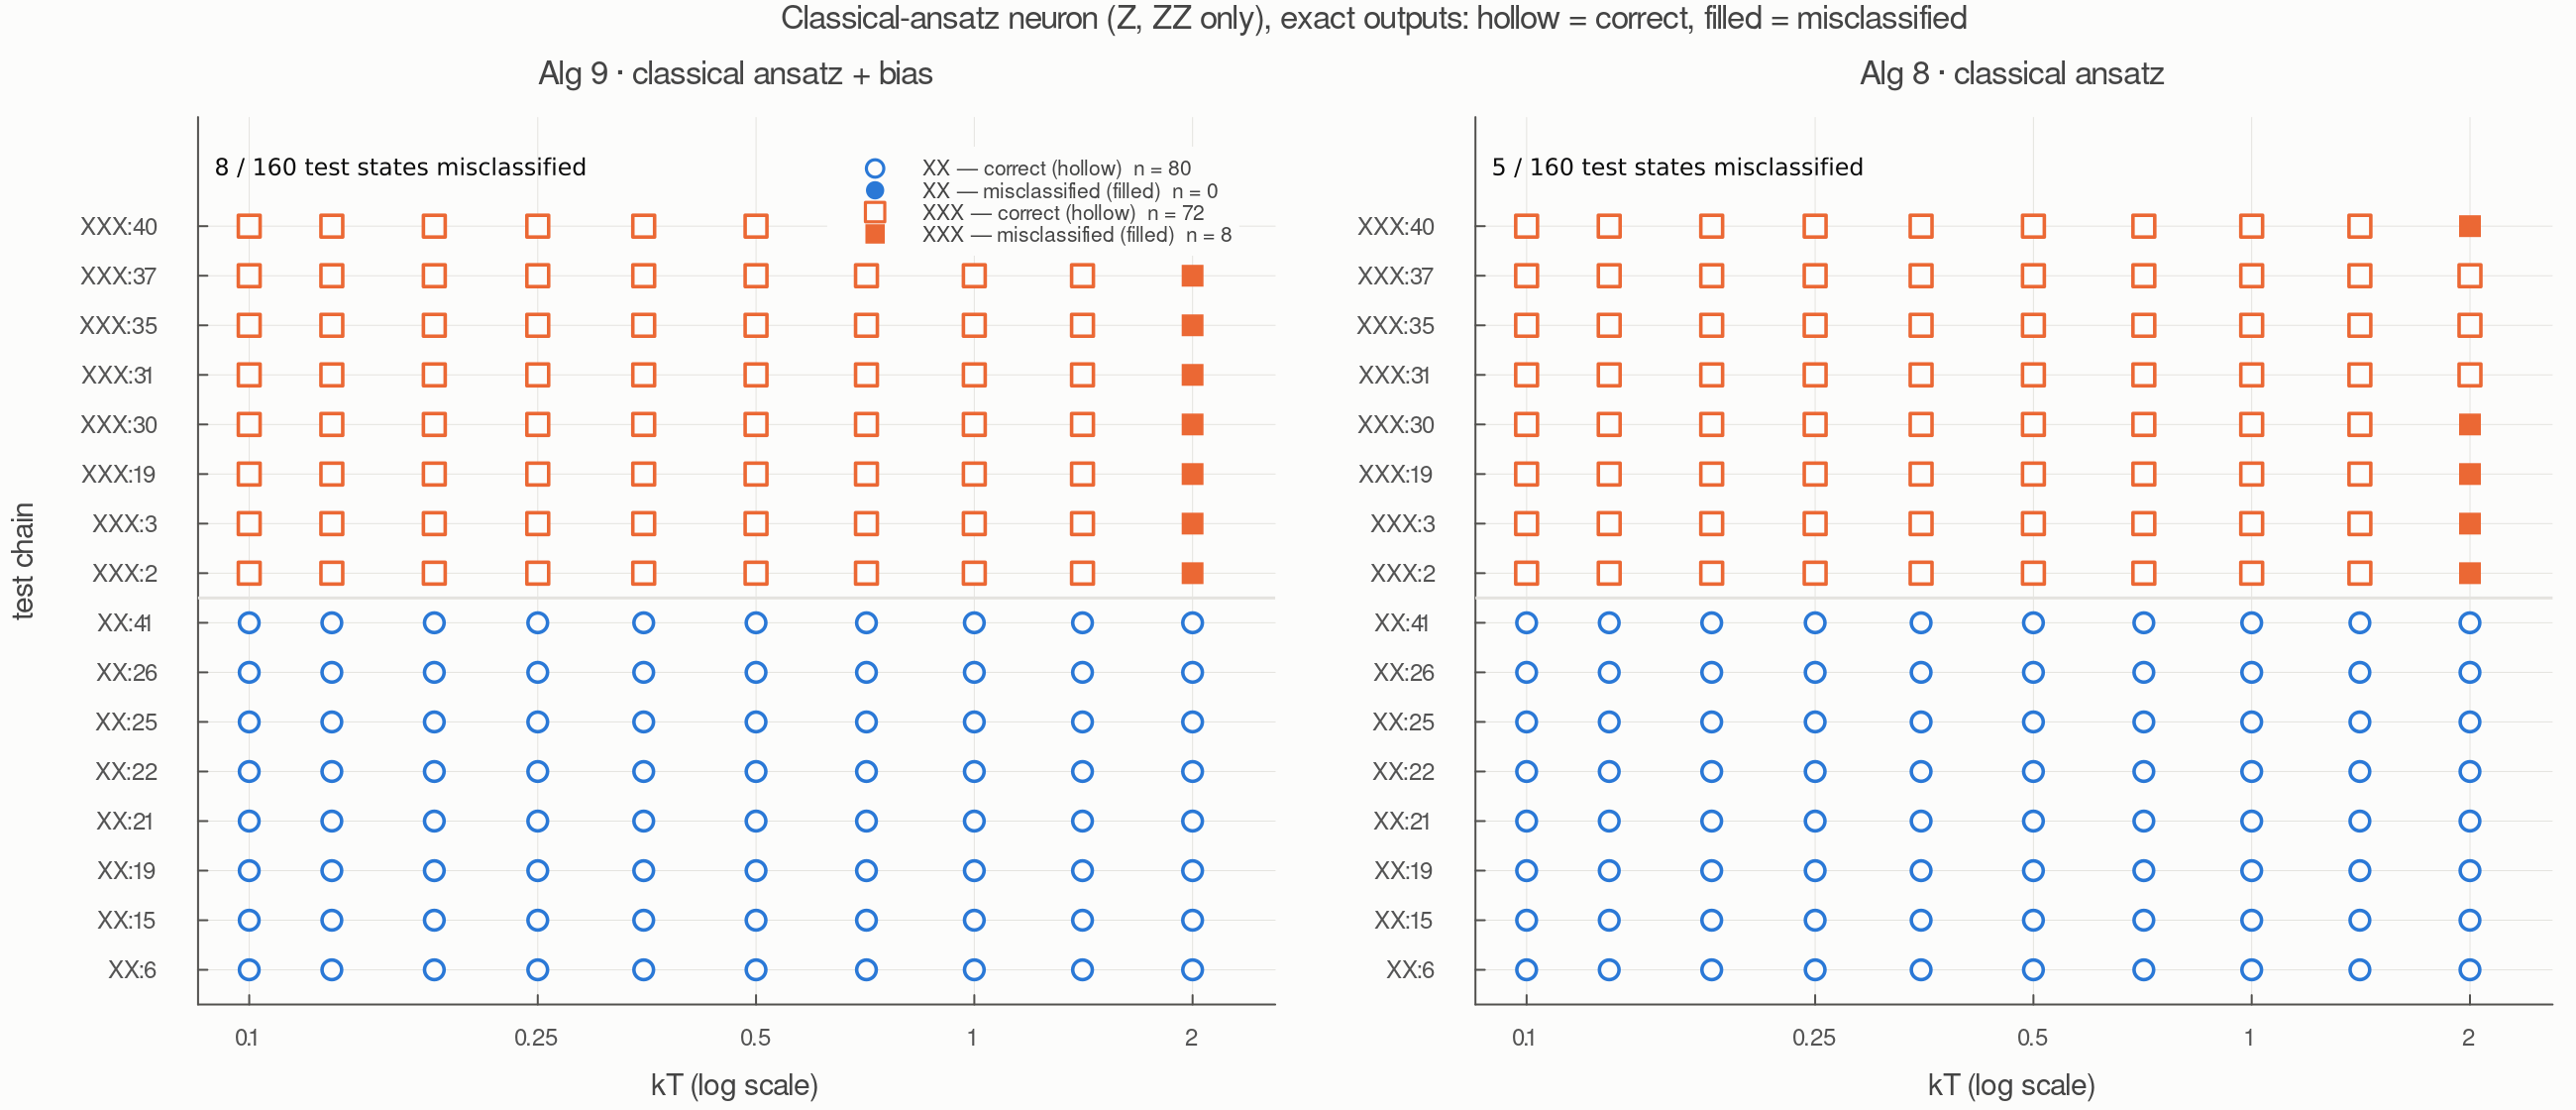

In [8]:
RERUN && runscript("train_xx_xxx_grelu.jl", "final", "kT", "classical")
foreach(showfig, ("B1_training", "C_test_scores", "D1_learned_theta", "F1_kT_transfer", "G_classical_ansatz", "G2_scatter_classical"))

## 4. The cost of training with finite shots

Two experiments:
- **`gradvar`:** the estimator error against the number of circuit runs.
- **`shots`:** training on single-shot gradients.

Both are slow (~75 min together).

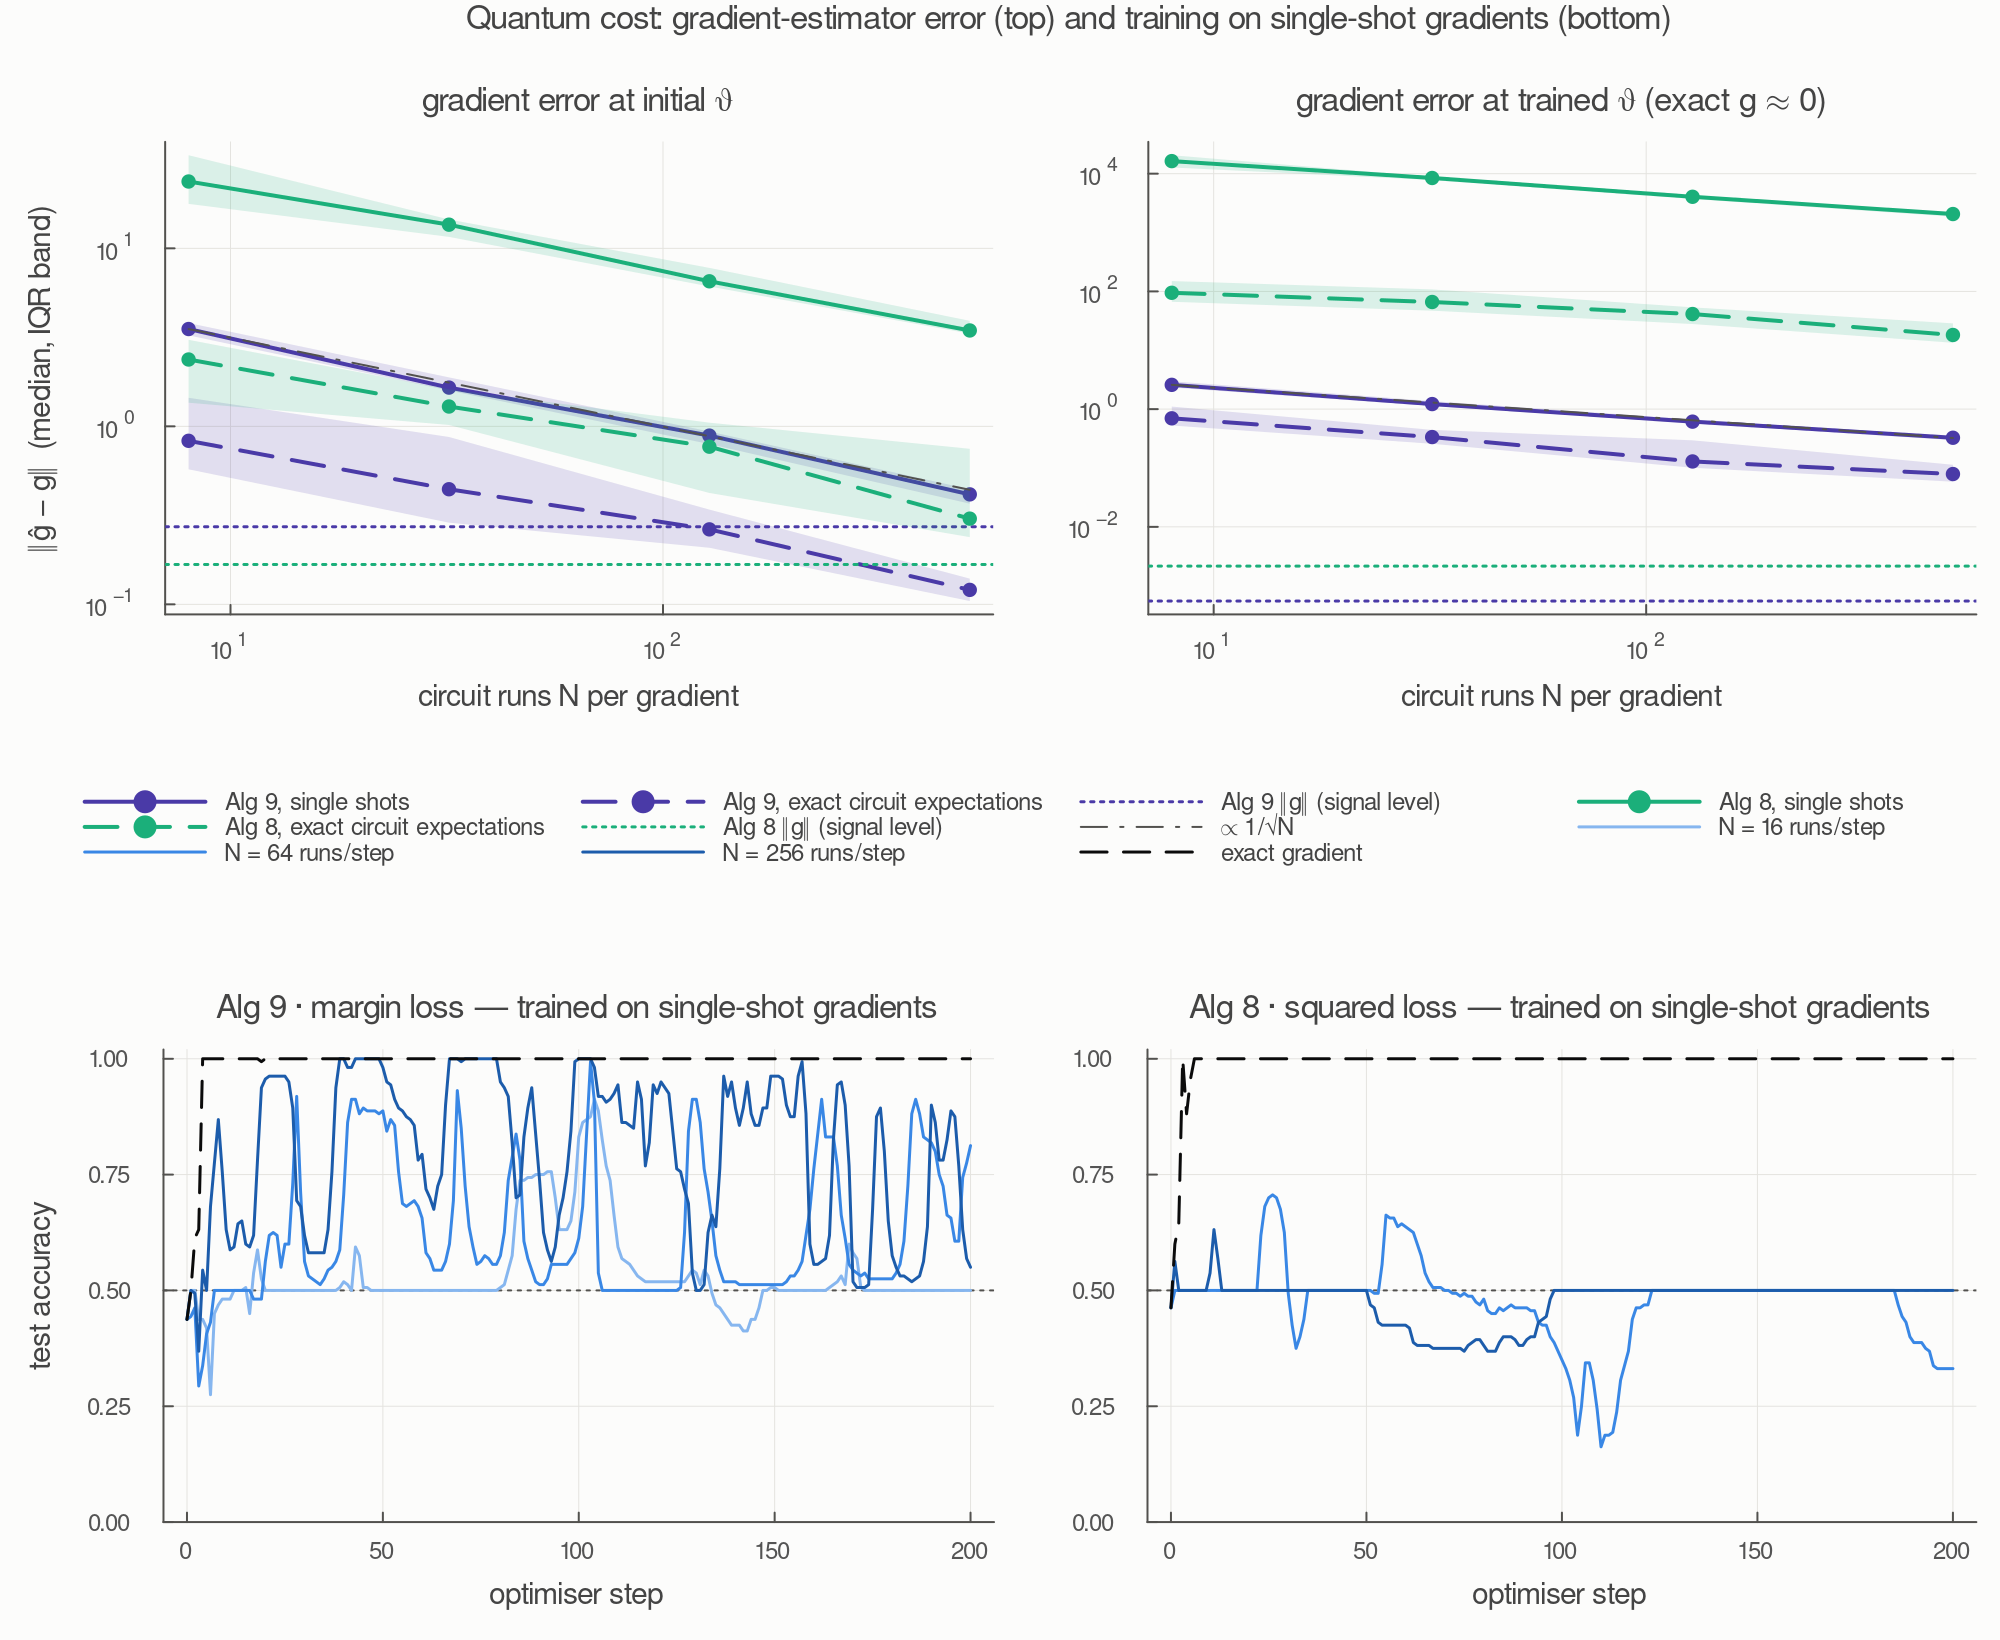

In [9]:
RERUN && runscript("train_xx_xxx_grelu.jl", "gradvar", "shots")
showfig("E_gradient_cost_and_shots")

## 5. Using the trained neuron: firing it (Gaussian Algorithm 5)

Algorithms 8 and 9 only *train* θ; the neuron is used by **firing** it. Algorithm 5 couples a Gaussian control qumode to one copy of ρ through exp(i x̂ ⊗ H/T₂), measures the qumode's momentum p, and outputs T₂·ReLU(p). In H(θ)'s eigenbasis one firing is **exactly** ReLU(E + T·Z): an energy E is drawn with its Born probability, and Z ~ N(0, 1). The cell below classifies the test set by firing both trained neurons. The Algorithm 9 model fires two neurons, on H and −H, because their difference estimates Tr[Hρ].

In [10]:
function fire_accuracy(kind, P, θ, N; seed=1)
    pte = P[2]
    eig = GN.diagonalise(GN.hamiltonian(pte.B, pte.paulis, θ))
    rng = MersenneTwister(seed)
    correct = map(1:GN.nstates(pte)) do m
        fs = FiringSampler(pte, eig, m)
        score = kind === :margin ? mean(fire(fs, rng) for _ in 1:N) - mean(fire(fs, rng; sign=-1) for _ in 1:N) :
                                   mean(fire(fs, rng) for _ in 1:N) - 0.5
        (score >= 0) == (pte.y[m] > 0)
    end
    mean(correct)
end
for N in (16, 64, 256, 1024)
    @printf("N = %4d firings/neuron:  Alg 9 model %.3f   Alg 8 model %.3f\n", N,
            fire_accuracy(:margin, P9, res9.theta, N), fire_accuracy(:square, P8, res8.theta, N))
end

N =   16 firings/neuron:  Alg 9 model 0.694   Alg 8 model 0.812
N =   64 firings/neuron:  Alg 9 model 0.900   Alg 8 model 0.912


N =  256 firings/neuron:  Alg 9 model 0.981   Alg 8 model 1.000
N = 1024 firings/neuron:  Alg 9 model 1.000   Alg 8 model 1.000


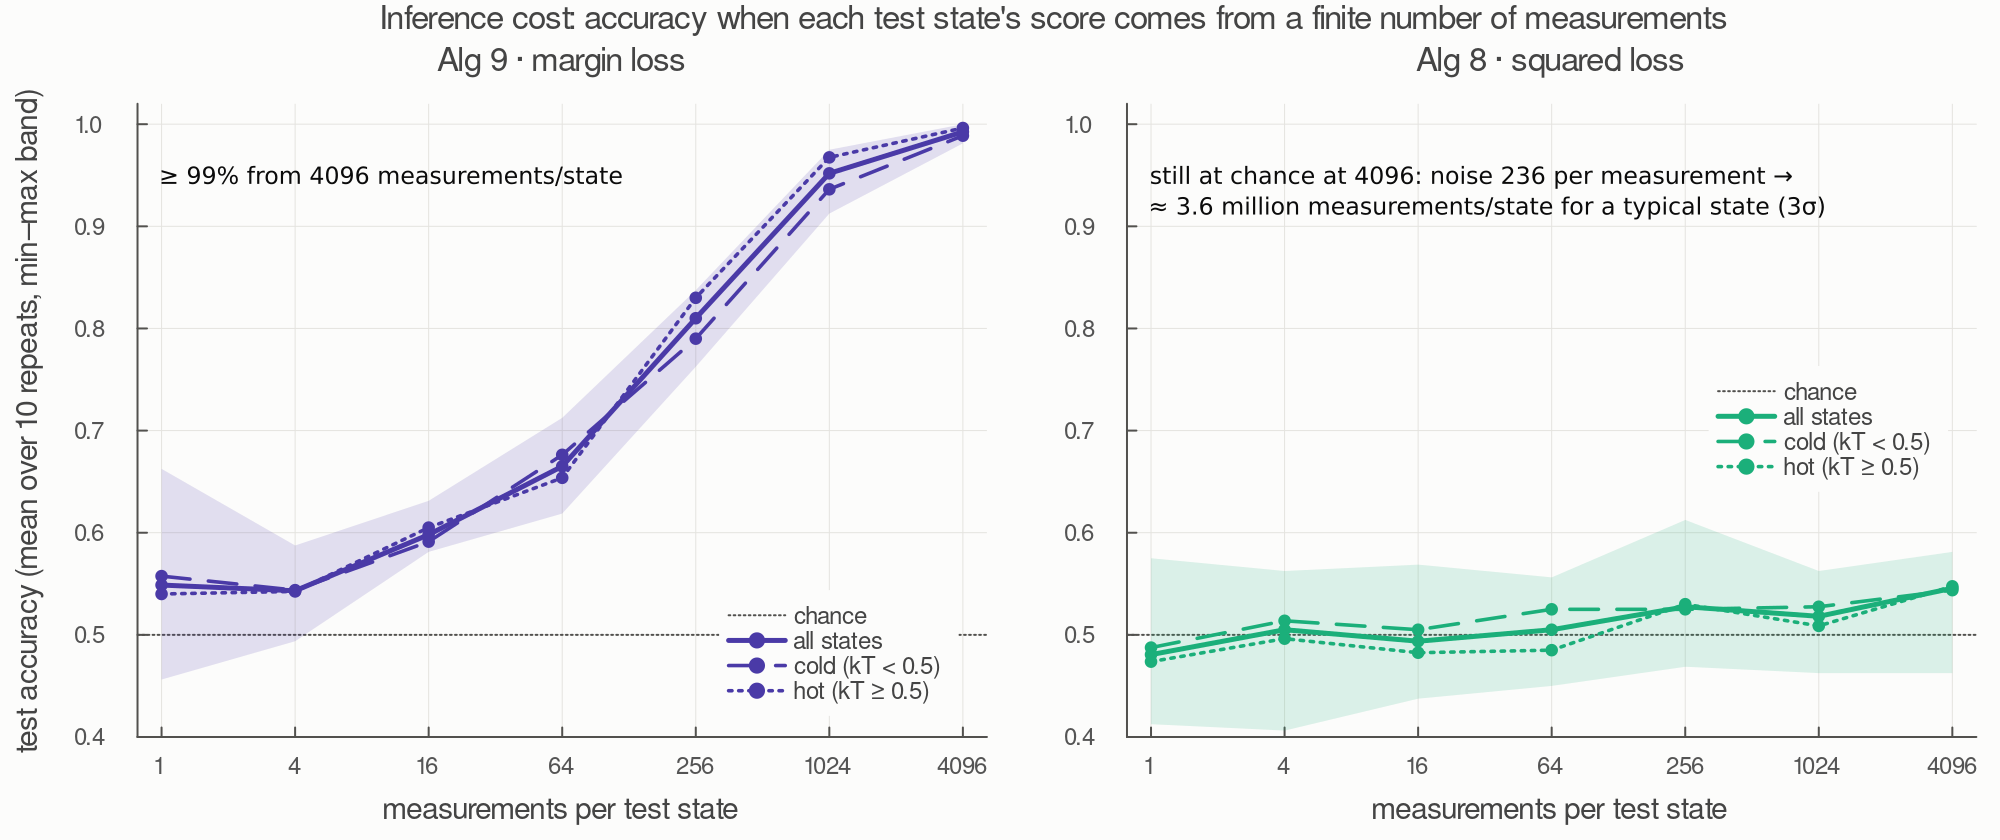

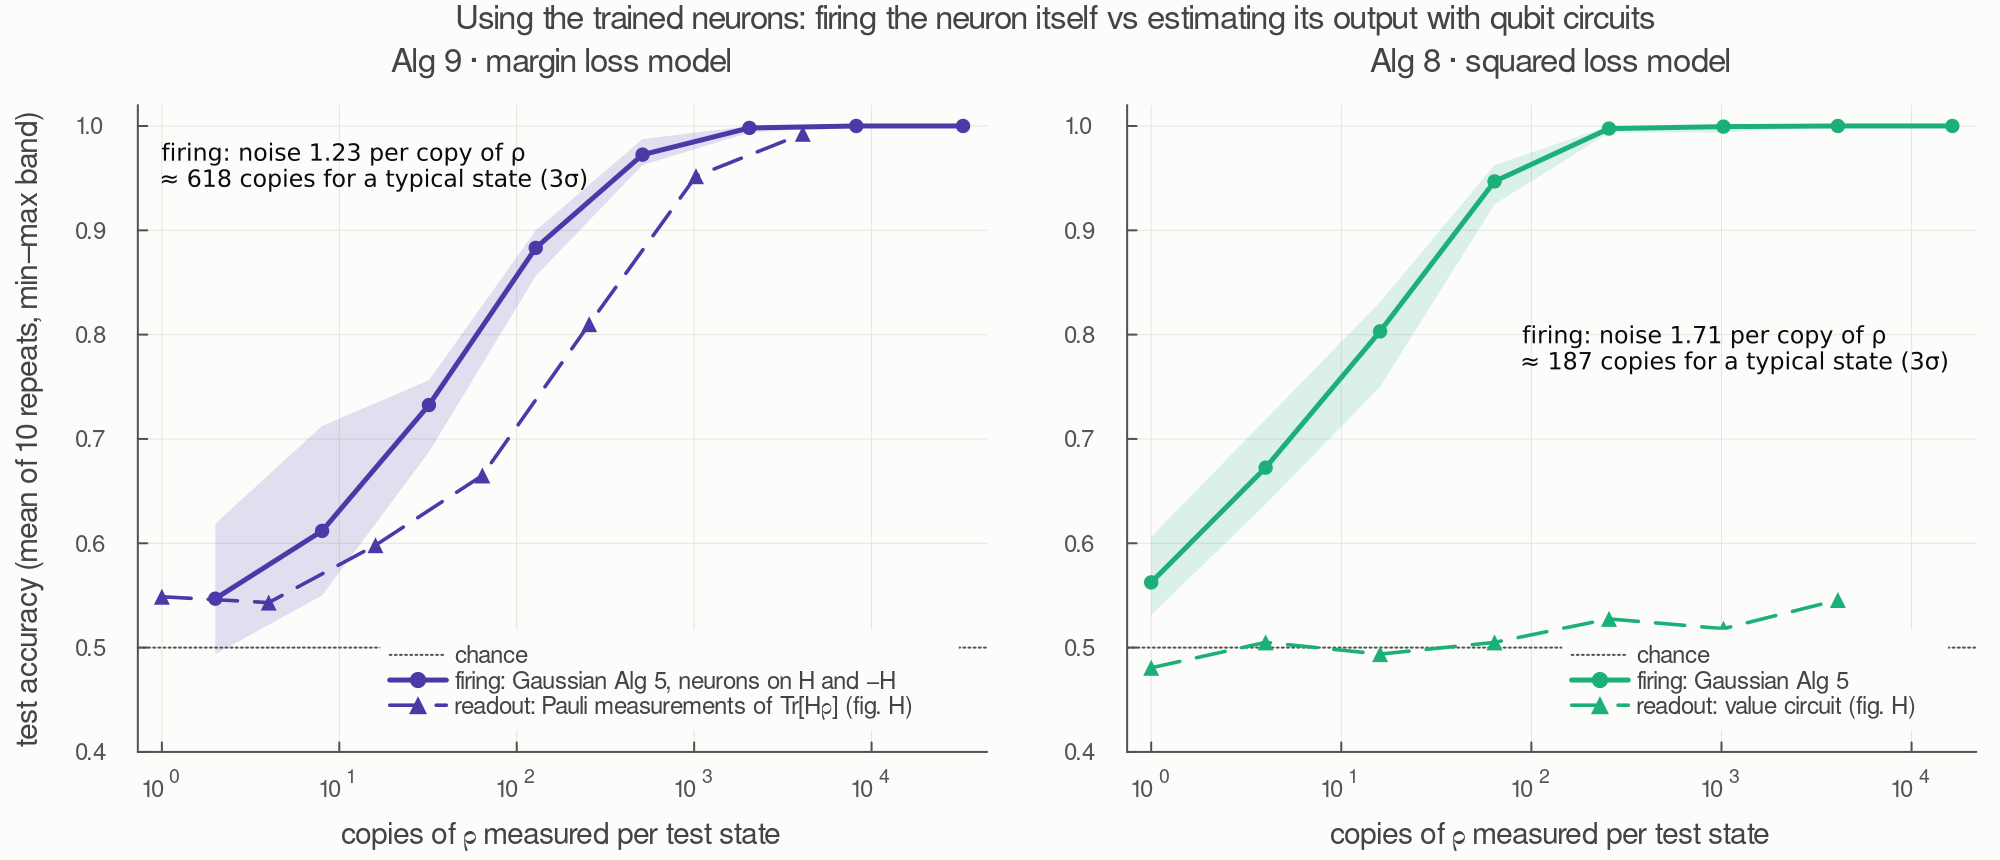

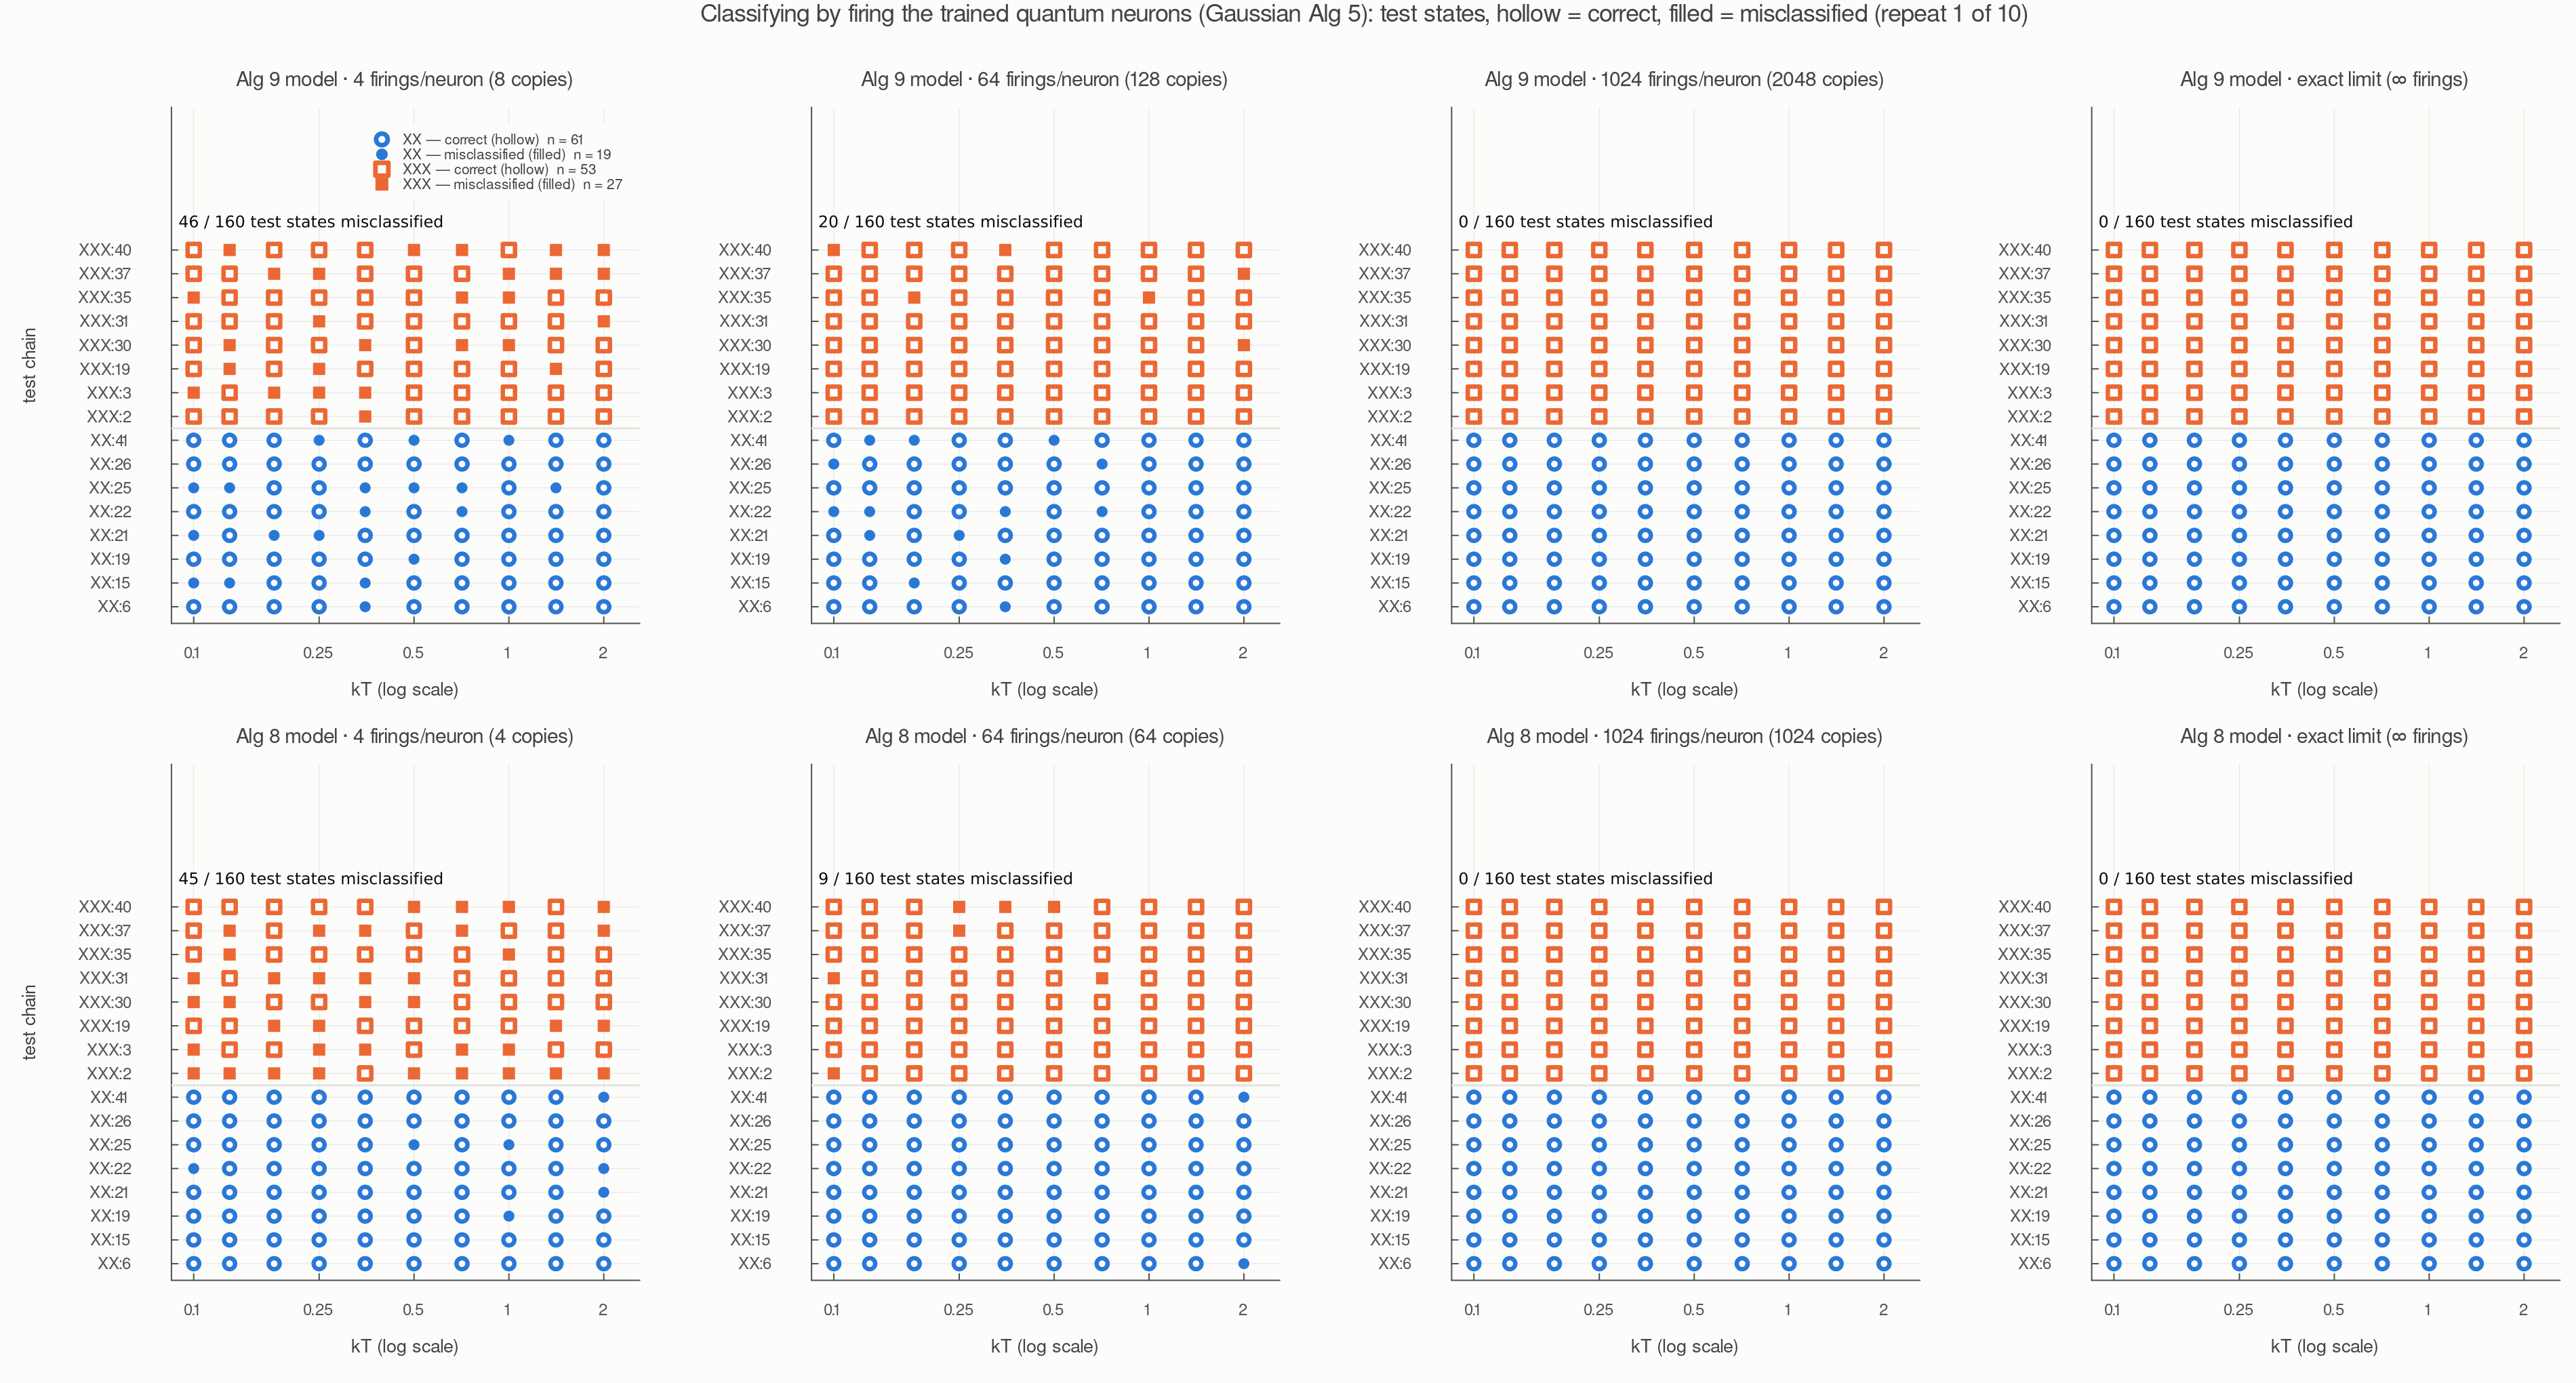

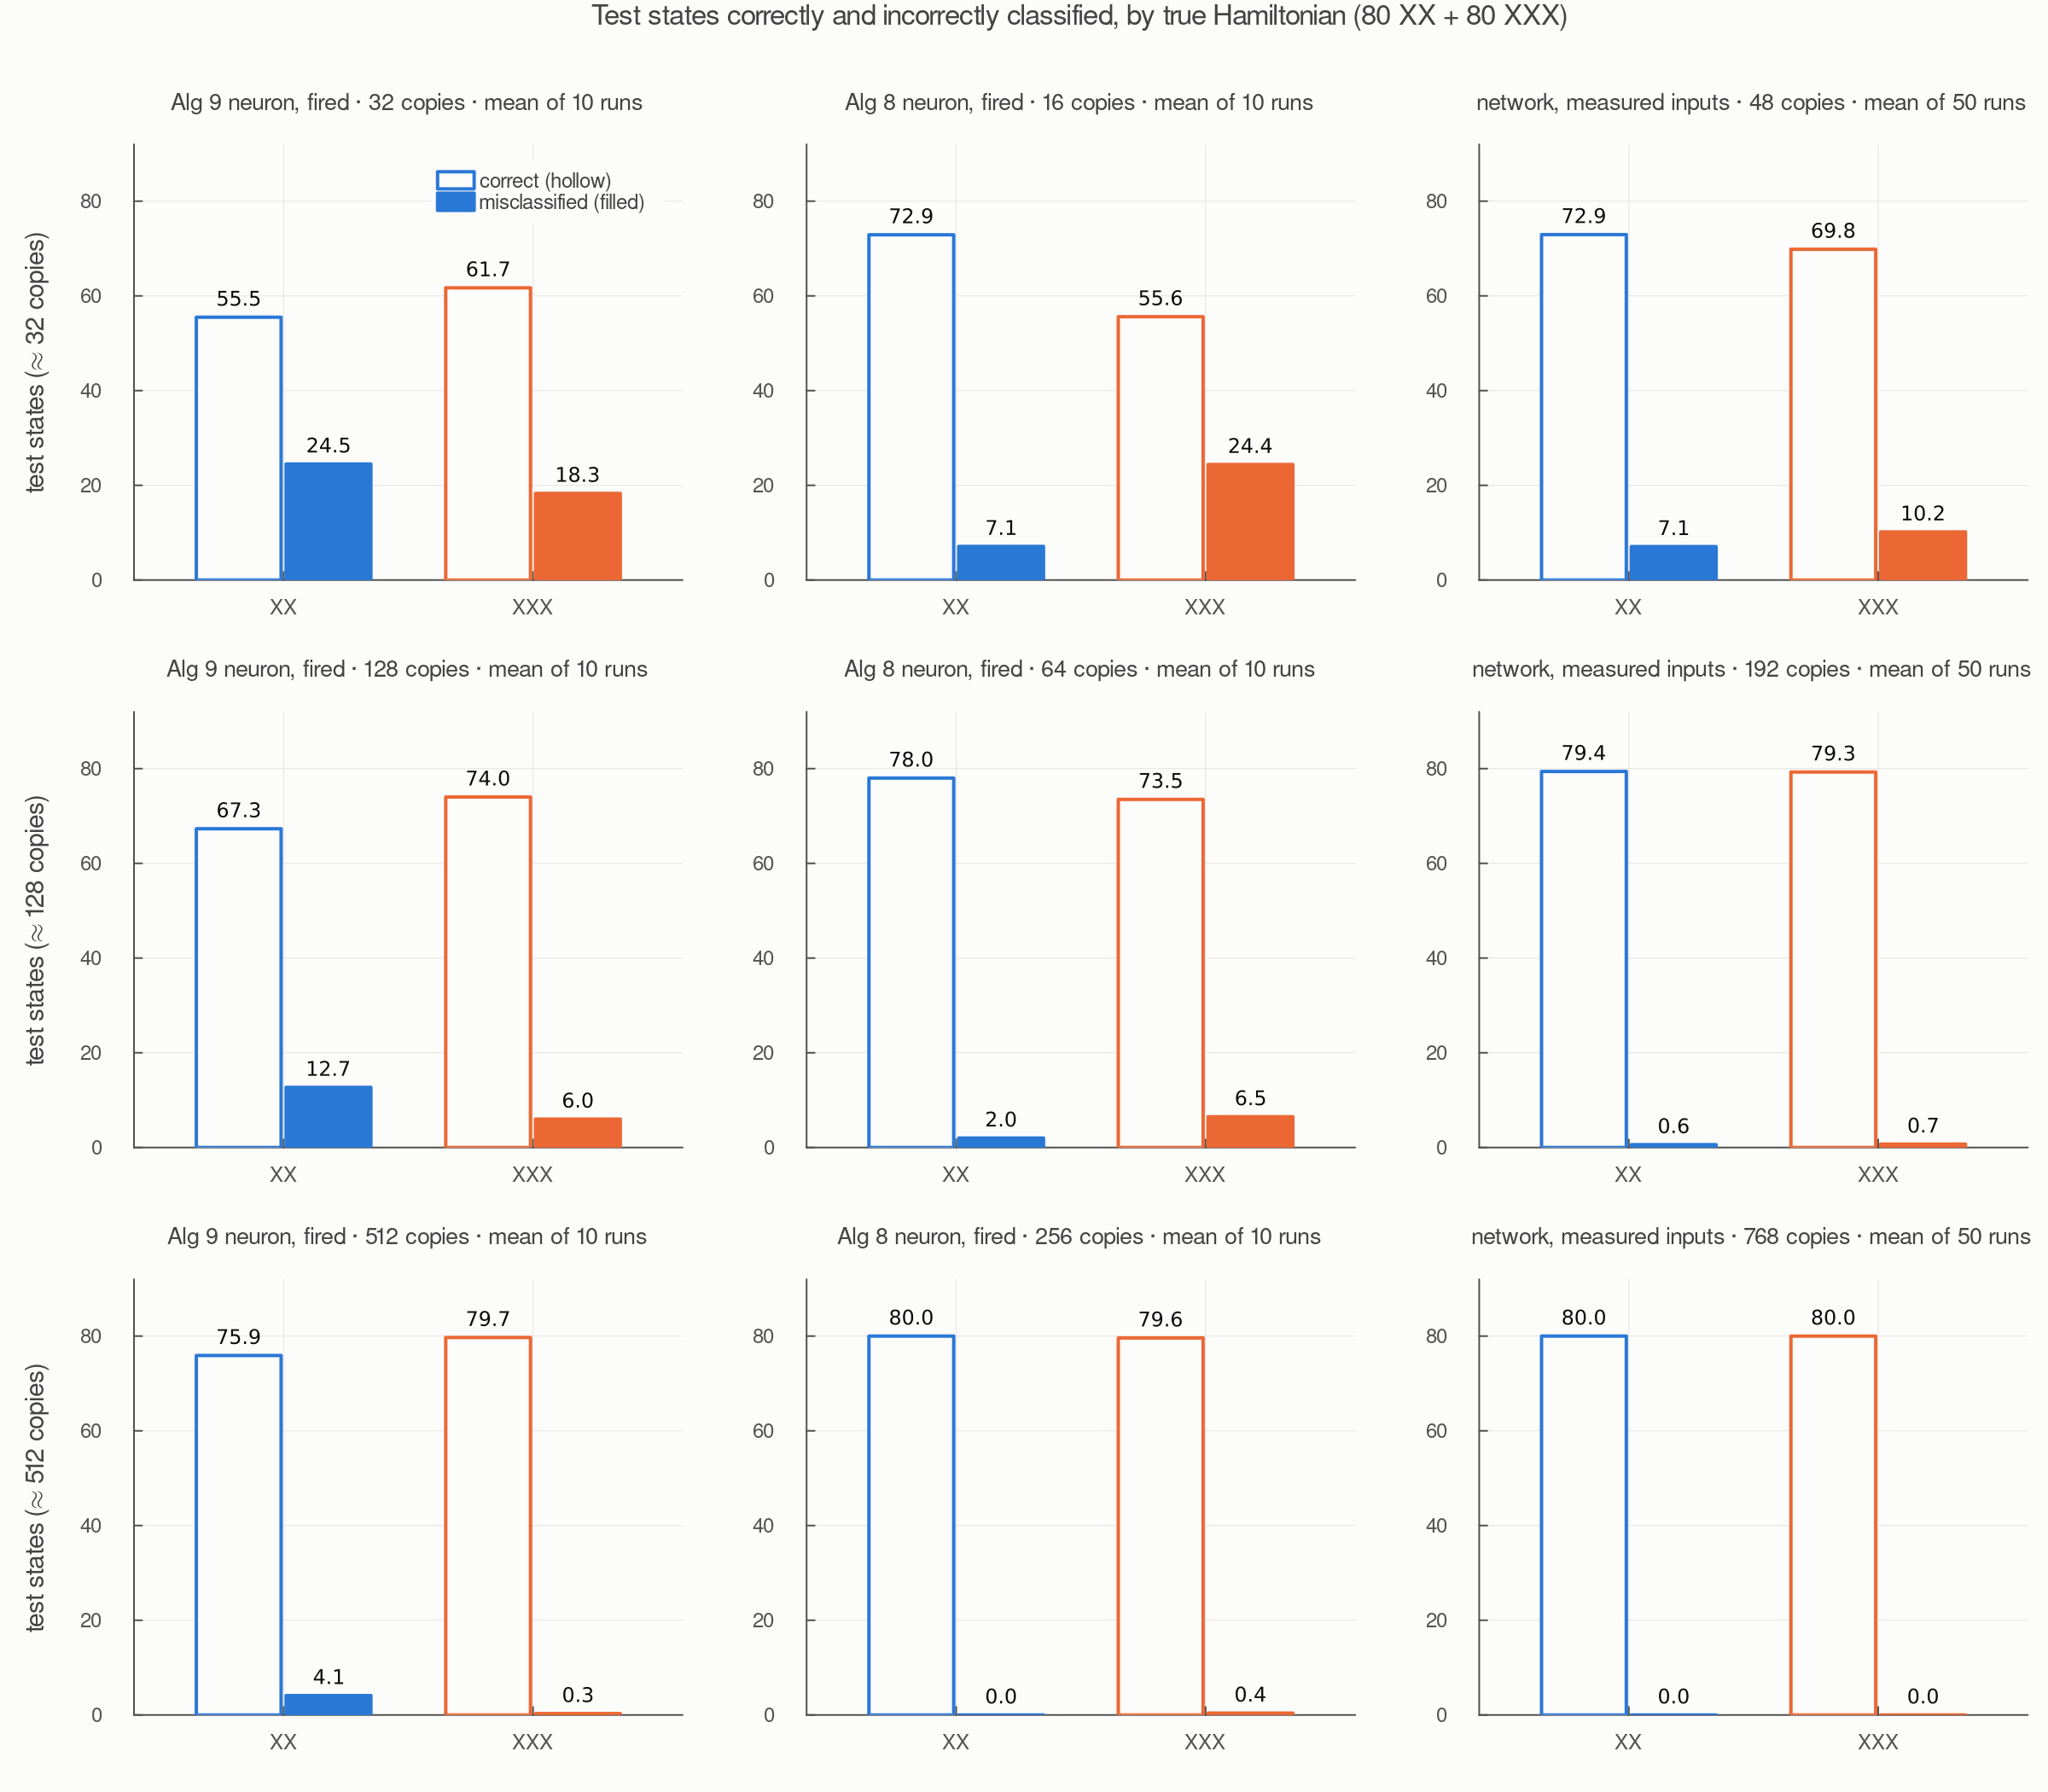

In [11]:
RERUN && runscript("train_xx_xxx_grelu.jl", "readout", "fire")
foreach(showfig, ("H_readout_cost", "I_firing_accuracy", "J_scatter_firing", "L_classified_counts"))

### The qumode, simulated explicitly in ITensor

To validate the reduction above, Algorithm 5 is also simulated literally on the n = 4 fixture:
- **the qumode:** an ITensor `"Boson"` site (a truncated Fock space with `a`, `a†`), starting in a Gaussian momentum state;
- **the coupling:** U = exp(i x̂ ⊗ H/T₂) via ITensor's `exp`, applied as UρU† with `apply(...; apply_dag=true)`;
- **the measurement:** the qubits are traced out, and the qumode's momentum distribution is read from its density matrix through Hermite functions.

Procedure and citations: REPORT §3.4 and references 2–6.

In [12]:
isdefined(Main, :QumodeITensor) || include(joinpath(EXPDIR, "src", "qumode_itensor.jl"))
let Q = QumodeITensor, fx = XXXData.load(joinpath(NBROOT, "data", "xx_xxx_thermal_states", "fixture_n4.h5"); verbose=false)
    paulis = [Pauli(fx.B, t) for t in terms_for(fx, :square)]
    prob = subproblem(fx, 1:length(fx), paulis, hp[:square].T)
    θ = train(:square, prob, nothing; l2=hp[:square].l2, monitor=false, verbose=false).theta
    sites = Q.siteinds_qubit(fx.n)
    Hm = Q.hamiltonian(sites, terms_for(fx, :square), θ)
    p = range(-25, 25; length=6001)
    m = 1
    ρ = Q.rho_itensor(sites, GN.to_full(fx.B, GN.rho(fx.B, fx.fams[fx.fam[m]], fx.beta[m])))
    exact = GN.neuron_outputs(prob, θ)[m]
    for d in (20, 40, 60)
        P, leak = Q.homodyne_density(Hm, ρ, sites, d, 1 / sqrt(2), prob.T * sqrt(2); p)
        μ, _ = Q.output_stats(P, p, prob.T * sqrt(2), [0.0])
        @printf("Fock cutoff d = %2d: mean output %.6f  vs exact Tr[GReLU(H)ρ] %.6f\n", d, μ, exact)
    end
end

Fock cutoff d = 20: mean output 0.065922  vs exact Tr[GReLU(H)ρ] 0.167779
Fock cutoff d = 40: mean output 0.140996  vs exact Tr[GReLU(H)ρ] 0.167779


Fock cutoff d = 60: mean output 0.167767  vs exact Tr[GReLU(H)ρ] 0.167779


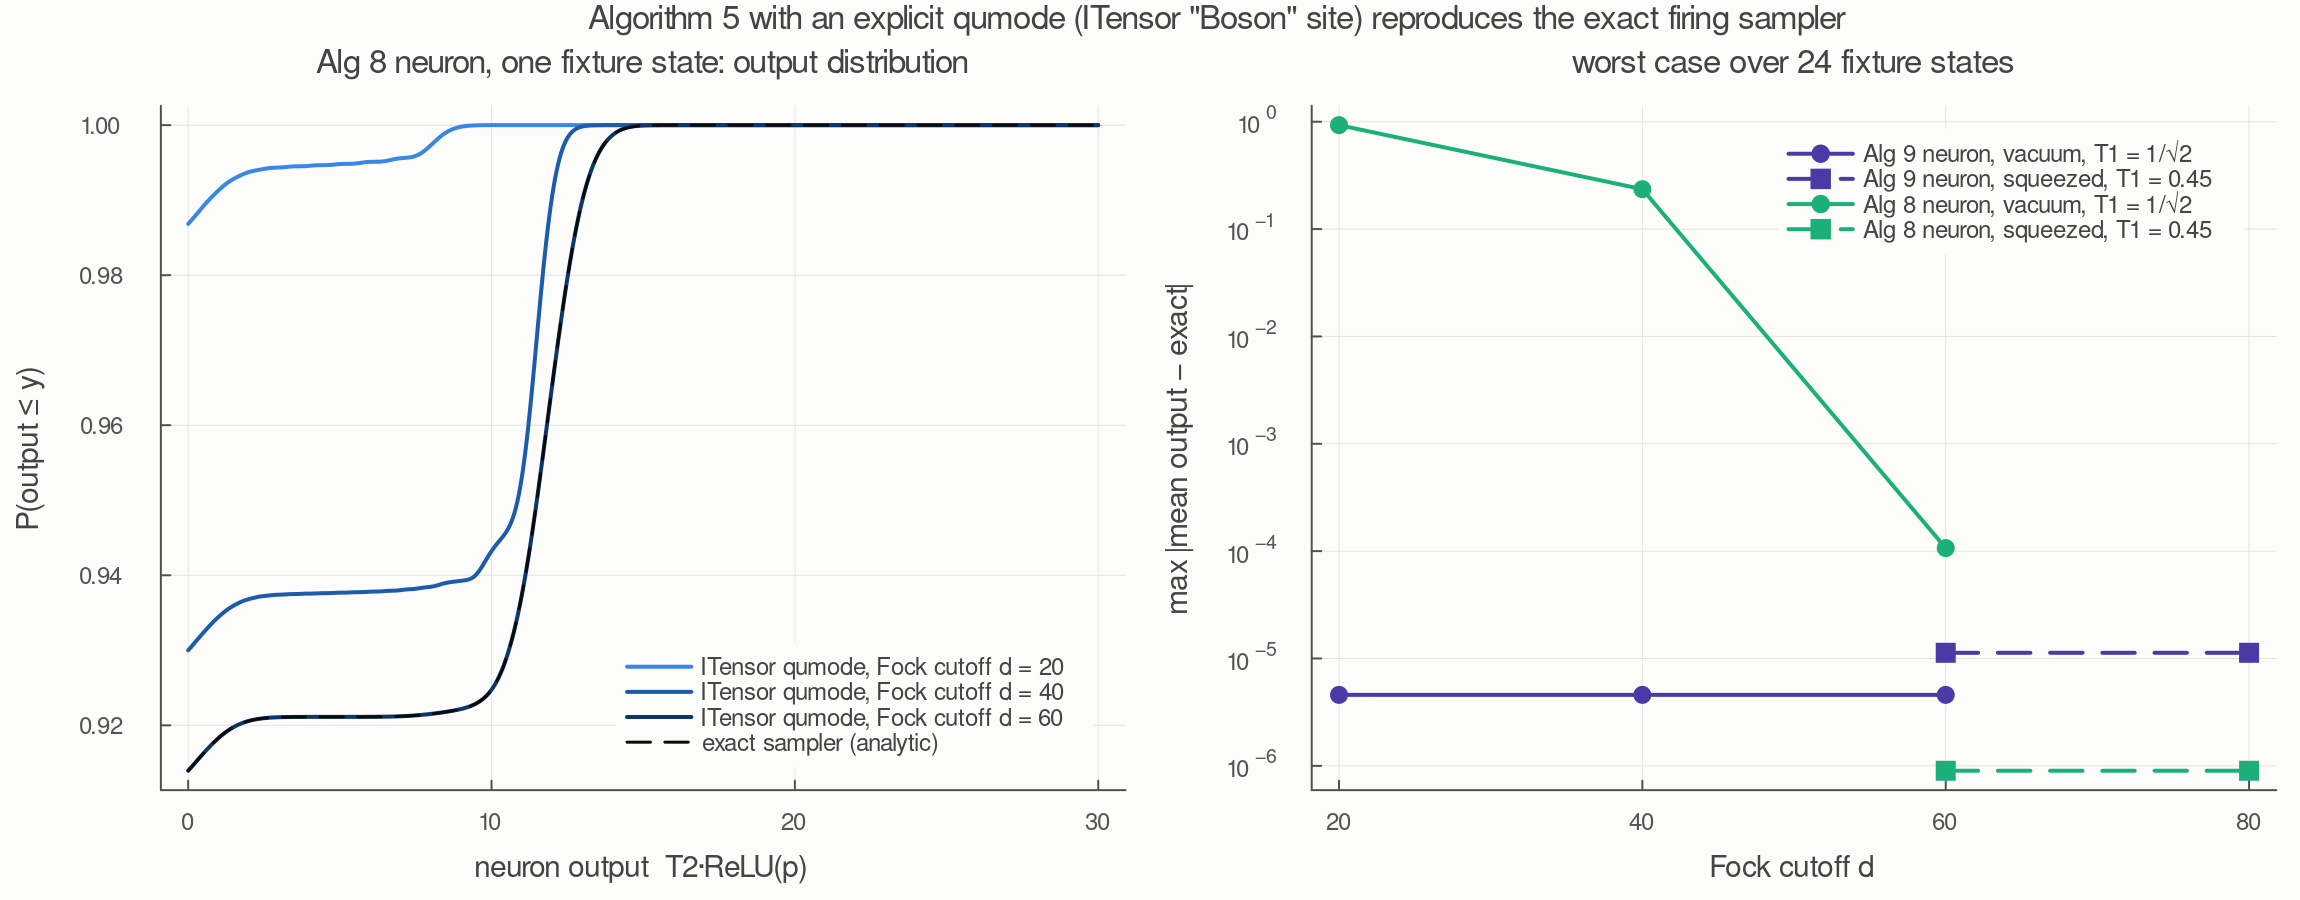

In [13]:
RERUN && runscript("qumode_itensor.jl")
showfig("I2_qumode_itensor")

## 6. The classical control: a feed-forward network

37 → 10 ReLU → 1 network, given the same 37 local expectation values as inputs. The script runs:
- 5 seeds;
- 50 label shuffles (the leakage control);
- temperature transfer;
- finite-measurement inputs (S/3 copies of ρ each in the Z, X and Y bases).

label-shuffle control (50 permutations): test accuracy 0.497 ± 0.121


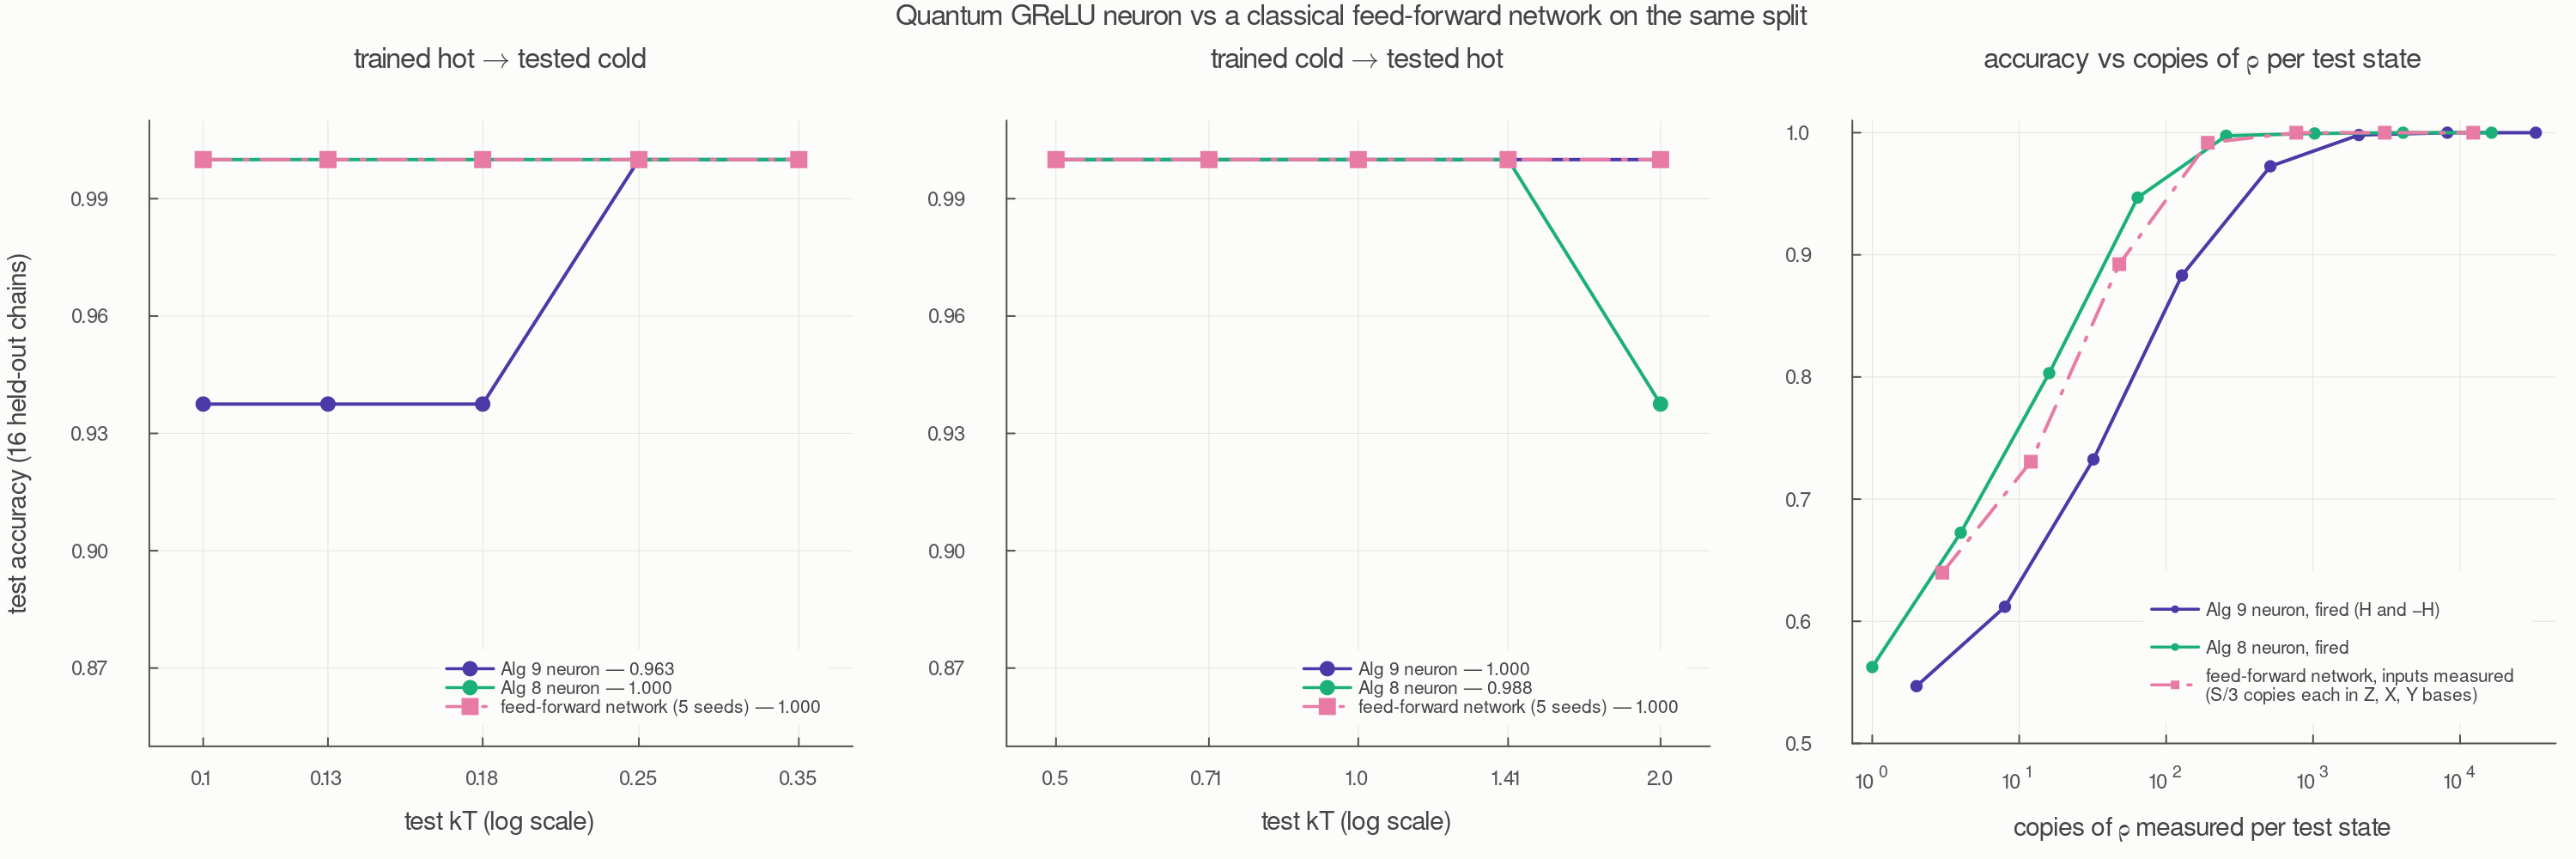

In [14]:
RERUN && runscript("ffnn_xx_xxx.jl")
s = readres("ffnn_shuffle50.csv")
@printf("label-shuffle control (50 permutations): test accuracy %.3f ± %.3f\n", mean(s["test_acc"]), std(s["test_acc"]))
showfig("K_quantum_vs_ffnn")

## 7. Metrics, figures and the report

In [15]:
runscript("metrics_xx_xxx.jl")    # prints the test-set metrics table; full table in results/classification_metrics.csv

model                                              acc  prec   rec    F1   IoU  mIoU   mAP   AUC
GReLU neuron, Alg 9 (quantum ansatz)             1.000 1.000 1.000 1.000 1.000 1.000 1.000 1.000
GReLU neuron, Alg 8 (quantum ansatz)             1.000 1.000 1.000 1.000 1.000 1.000 1.000 1.000
GReLU neuron, Alg 9 (classical ansatz + bias)    0.950 1.000 0.900 0.947 0.900 0.905 0.969 0.968
GReLU neuron, Alg 8 (classical ansatz)           0.969 1.000 0.938 0.968 0.938 0.939 0.999 0.999
Feed-forward ReLU network (seed 1)               1.000 1.000 1.000 1.000 1.000 1.000 1.000 1.000
GReLU neuron, Alg 9, fired 16×/neuron (32 copies of ρ; mean of 10 repeats) 0.733 0.716 0.771 0.742 0.590 0.578 0.814 0.815
GReLU neuron, Alg 9, fired 64×/neuron (128 copies of ρ; mean of 10 repeats) 0.883 0.854 0.925 0.888 0.799 0.791 0.956 0.954
GReLU neuron, Alg 9, fired 256×/neuron (512 copies of ρ; mean of 10 repeats) 0.973 0.951 0.996 0.973 0.948 0.947 0.999 0.999
GReLU neuron, Alg 9, fired 1024×/neuron (2048 

In [16]:
runscript("plot_xx_xxx_grelu.jl")             # every figure, from results/
run(`python3 $(joinpath(EXPDIR, "src", "build_report_pdf.py"))`);   # REPORT.md -> REPORT.pdf (needs Chrome)

wrote experiments/xx_xxx_grelu/figures/A2_correlators.{png,pdf}


wrote experiments/xx_xxx_grelu/figures/B1_training.{png,pdf}


wrote experiments/xx_xxx_grelu/figures/C_test_scores.{png,pdf}


wrote experiments/xx_xxx_grelu/figures/D1_learned_theta.{png,pdf}


wrote experiments/xx_xxx_grelu/figures/E_gradient_cost_and_shots.{png,pdf}


...

wrote experiments/xx_xxx_grelu/figures/I2_qumode_itensor.{png,pdf}


wrote experiments/xx_xxx_grelu/figures/J_scatter_firing.{png,pdf}


wrote experiments/xx_xxx_grelu/figures/K_quantum_vs_ffnn.{png,pdf}


wrote experiments/xx_xxx_grelu/figures/L_classified_counts.{png,pdf}


wrote experiments/xx_xxx_grelu/REPORT.pdf
